# HEART: Hierarchical Embedding for Affective and Riemannian Trajectories

### Using the last 30s of recordings

Segment boundaries (seconds) for each emotion [last 30 s only]:
Positive: Mean boundary = 14.87s ± 8.83s | Avg # boundaries = 1.53 (15 trials)
Neutral : Mean boundary = 17.29s ± 7.72s | Avg # boundaries = 1.60 (15 trials)
Negative: Mean boundary = 12.43s ± 8.78s | Avg # boundaries = 1.53 (15 trials)


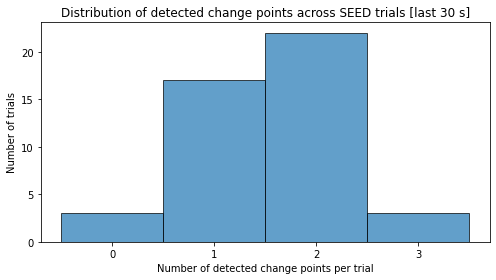


Estimated optimal number of change points per trial ≈ 2


In [15]:
import os
import numpy as np
from collections import defaultdict
from sklearn.covariance import OAS
import scipy.io
import matplotlib.pyplot as plt

# === Configuration ===
fs = 200  # Hz, SEED sampling rate
window_sec = 1
window_samples = fs * window_sec
last_sec = 30  # Use only last 30s of trial
data_dir = r"C:\Users\jonah\Downloads\Emotions\SEED\Preprocessed_EEG"

# SEED emotion labels (fixed order across trials)
seed_labels = [1, 0, -1, -1, 0, 1, -1, 0, 1, 1, 0, -1, 0, 1, -1]
label_map = {1: "Positive", 0: "Neutral", -1: "Negative"}

# === Helper functions ===

def compute_covariance_oas(X):
    """Compute robust covariance (OAS) for EEG window."""
    oas = OAS()
    oas.fit(X.T)
    cov = oas.covariance_
    cov += 1e-6 * np.eye(cov.shape[0])  # stability
    return cov

def extract_cov_features(eeg_trial, window_samples):
    """Extract upper-triangular covariance features for each 1s window."""
    n_channels, n_samples = eeg_trial.shape
    n_windows = n_samples // window_samples
    features = []
    for w in range(n_windows):
        start = w * window_samples
        end = start + window_samples
        segment = eeg_trial[:, start:end]
        cov = compute_covariance_oas(segment)
        iu = np.triu_indices(n_channels)
        features.append(cov[iu])
    return np.array(features)

def find_change_points(features, threshold_std=2.0, max_points=6):
    """Detect significant feature-change points using threshold on ΔF."""
    if len(features) < 2:
        return np.array([])

    distances = np.linalg.norm(np.diff(features, axis=0), axis=1)
    threshold = np.mean(distances) + threshold_std * np.std(distances)
    change_idxs = np.where(distances > threshold)[0] + 1
    return change_idxs[:max_points]

# === Main processing ===

emotion_boundaries = defaultdict(list)
change_point_counts = defaultdict(list)

for filename in sorted(os.listdir(data_dir)):
    if not filename.endswith(".mat"):
        continue

    mat_path = os.path.join(data_dir, filename)
    mat_data = scipy.io.loadmat(mat_path)
    trial_keys = [k for k in mat_data.keys() if k.startswith("djc_eeg")]
    trial_keys = sorted(trial_keys, key=lambda x: int(x.replace("djc_eeg", "")))

    for idx, key in enumerate(trial_keys):
        eeg_trial = np.squeeze(mat_data[key])  # shape: (n_channels, n_samples)
        emotion = label_map[seed_labels[idx]]

        # --- Use only the last 30 seconds ---
        last_30s_samples = last_sec * fs
        if eeg_trial.shape[1] > last_30s_samples:
            eeg_trial = eeg_trial[:, -last_30s_samples:]

        # --- Feature extraction and change-point detection ---
        features = extract_cov_features(eeg_trial, window_samples)
        change_idxs = find_change_points(features, threshold_std=2.0, max_points=5)

        # Save boundary times and counts
        emotion_boundaries[emotion].extend(change_idxs * window_sec)
        change_point_counts[emotion].append(len(change_idxs))

# === Summary statistics ===
print("Segment boundaries (seconds) for each emotion [last 30 s only]:")
for emotion, boundaries in emotion_boundaries.items():
    avg_b = np.mean(boundaries) if boundaries else 0
    std_b = np.std(boundaries) if boundaries else 0
    avg_n = np.mean(change_point_counts[emotion])
    print(f"{emotion:8s}: Mean boundary = {avg_b:.2f}s ± {std_b:.2f}s | "
          f"Avg # boundaries = {avg_n:.2f} ({len(change_point_counts[emotion])} trials)")

# === Combine and visualize ===
all_counts = []
all_emotions = []
for emotion, counts in change_point_counts.items():
    all_counts.extend(counts)
    all_emotions.extend([emotion] * len(counts))

# Histogram of number of change points
plt.figure(figsize=(7, 4))
plt.hist(all_counts, bins=np.arange(0, max(all_counts) + 2) - 0.5, edgecolor='black', alpha=0.7)
plt.xlabel("Number of detected change points per trial")
plt.ylabel("Number of trials")
plt.title("Distribution of detected change points across SEED trials [last 30 s]")
plt.xticks(range(int(max(all_counts)) + 1))
plt.tight_layout()
plt.show()

# === Optimal number estimation ===
optimal_n = int(np.median(all_counts))
print(f"\nEstimated optimal number of change points per trial ≈ {optimal_n}")

Average boundary positions (seconds) per emotion [last 30 s only]:

Positive:
  Boundary 1: 11.73 ± 8.44 s (15 trials)
  Boundary 2: 18.87 ± 7.41 s (15 trials)

Neutral:
  Boundary 1: 14.73 ± 7.11 s (15 trials)
  Boundary 2: 19.47 ± 8.12 s (15 trials)

Negative:
  Boundary 1: 10.00 ± 7.85 s (15 trials)
  Boundary 2: 16.40 ± 7.58 s (15 trials)



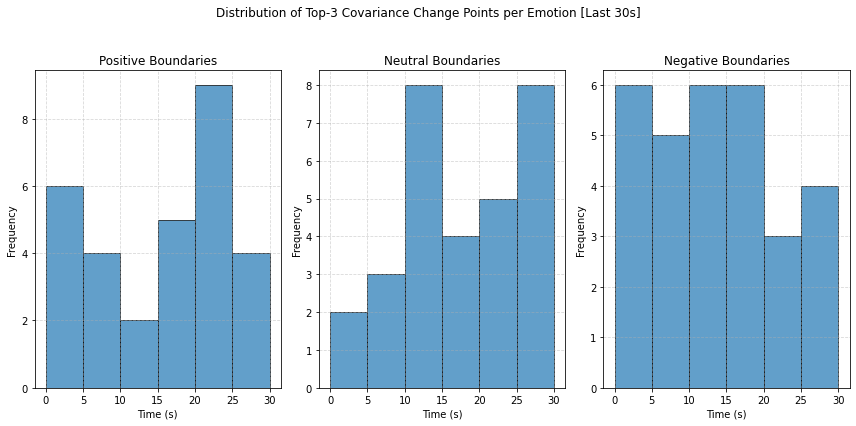

In [19]:
import os
import numpy as np
from collections import defaultdict
from sklearn.covariance import OAS
import scipy.io
import matplotlib.pyplot as plt

# --- Configuration ---
fs = 200  # Hz
window_sec = 1
window_samples = fs * window_sec
last_sec = 30  # Use only last 30 seconds
data_dir = r"C:\Users\jonah\Downloads\Emotions\SEED\Preprocessed_EEG"

# Emotion labels for SEED
seed_labels = [1, 0, -1, -1, 0, 1, -1, 0, 1, 1, 0, -1, 0, 1, -1]
label_map = {1: "Positive", 0: "Neutral", -1: "Negative"}

# --- Helper functions ---
def compute_covariance_oas(X):
    """Compute stable covariance using OAS shrinkage."""
    oas = OAS()
    oas.fit(X.T)
    cov = oas.covariance_
    cov += 1e-6 * np.eye(cov.shape[0])
    return cov

def extract_cov_features(eeg_trial, window_samples):
    """Extract covariance-based EEG features for each 1-second window."""
    n_channels, n_samples = eeg_trial.shape
    n_windows = n_samples // window_samples
    features = []
    for w in range(n_windows):
        start = w * window_samples
        end = start + window_samples
        segment = eeg_trial[:, start:end]
        cov = compute_covariance_oas(segment)
        iu = np.triu_indices(n_channels)
        features.append(cov[iu])
    return np.array(features)

def find_top_change_points(features, max_points=3):
    """
    Find up to `max_points` strongest change points by largest 
    distance between consecutive covariance feature vectors.
    """
    if len(features) < 2:
        return np.array([])

    distances = np.linalg.norm(np.diff(features, axis=0), axis=1)

    # Sort distances descending and take top-N indices
    top_indices = np.argsort(distances)[::-1][:max_points]

    # Convert to boundary indices (next segment start)
    change_idxs = np.sort(top_indices + 1)
    return change_idxs

# --- Main processing ---
emotion_boundaries = defaultdict(list)

for filename in sorted(os.listdir(data_dir)):
    if not filename.endswith(".mat"):
        continue

    mat_path = os.path.join(data_dir, filename)
    mat_data = scipy.io.loadmat(mat_path)
    trial_keys = [k for k in mat_data.keys() if k.startswith("djc_eeg")]
    trial_keys = sorted(trial_keys, key=lambda x: int(x.replace("djc_eeg", "")))

    for idx, key in enumerate(trial_keys):
        eeg_trial = np.squeeze(mat_data[key])
        emotion = label_map[seed_labels[idx]]

        # --- Use only the last 30 seconds of the trial ---
        last_samples = last_sec * fs
        if eeg_trial.shape[1] > last_samples:
            eeg_trial = eeg_trial[:, -last_samples:]

        # Compute covariance-based features
        features = extract_cov_features(eeg_trial, window_samples)

        # Find top 3 strongest change points
        change_points = find_top_change_points(features, max_points=2)

        if len(change_points) > 0:
            # Store boundary times in seconds
            emotion_boundaries[emotion].append(change_points * window_sec)

# --- Aggregate across trials ---
print("Average boundary positions (seconds) per emotion [last 30 s only]:\n")

for emotion, all_boundaries in emotion_boundaries.items():
    all_boundaries = [np.array(b) for b in all_boundaries if len(b) > 0]
    max_points = max(len(b) for b in all_boundaries)

    print(f"{emotion}:")
    for i in range(max_points):
        valid_points = [b[i] for b in all_boundaries if len(b) > i]
        if len(valid_points) == 0:
            continue
        avg_b = np.mean(valid_points)
        std_b = np.std(valid_points)
        print(f"  Boundary {i+1}: {avg_b:.2f} ± {std_b:.2f} s ({len(valid_points)} trials)")
    print()

# --- Plot histograms of boundary distributions ---
plt.figure(figsize=(12, 6))
bins = np.arange(0, last_sec + 5, 5)  # 5-second bins up to last_sec

for i, (emotion, all_boundaries) in enumerate(emotion_boundaries.items(), 1):
    plt.subplot(1, 3, i)
    flat_bounds = np.concatenate(all_boundaries)
    plt.hist(flat_bounds, bins=bins, alpha=0.7, edgecolor='black')
    plt.title(f"{emotion} Boundaries")
    plt.xlabel("Time (s)")
    plt.ylabel("Frequency")
    plt.grid(True, linestyle="--", alpha=0.5)

plt.suptitle("Distribution of Top-3 Covariance Change Points per Emotion [Last 30s]")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [2]:
import re
import os
import pickle
import numpy as np
import scipy.io
from sklearn.covariance import OAS
from scipy.linalg import logm
import mne

# -----------------------------------------------------------
# Configuration
# -----------------------------------------------------------
fs = 200  # Hz
last_sec = 30  # Use only the last 30 seconds
data_dir = r"C:\Users\jonah\Downloads\Emotions\SEED\Preprocessed_EEG"
output_path = "seed_heart_features_multi_last30s_preprocessed.pkl"

# SEED emotion mapping and average boundaries
seed_labels = [1, 0, -1, -1, 0, 1, -1, 0, 1, 1, 0, -1, 0, 1, -1]
label_map = {1: "Positive", 0: "Neutral", -1: "Negative"}

emotion_mean_boundaries = {
    "Positive": [11.73, 18.87],
    "Neutral":  [14.73, 19.47],
    "Negative": [10.00, 16.50]
}

# Preprocessing parameters
l_freq, h_freq = 0.05, 47  # Hz
fir_window = 'hamming'
fir_order = 825

# -----------------------------------------------------------
# Utility functions
# -----------------------------------------------------------
def compute_covariance(X):
    """Compute OAS covariance matrix for stability."""
    oas = OAS()
    oas.fit(X.T)
    cov = oas.covariance_
    cov += 1e-6 * np.eye(cov.shape[0])
    return cov

def geodesic_distance(C1, C2):
    """Compute Riemannian (geodesic) distance between covariance matrices."""
    sqrt_C1 = np.linalg.cholesky(C1)
    inv_sqrt_C1 = np.linalg.inv(sqrt_C1)
    C2_norm = inv_sqrt_C1 @ C2 @ inv_sqrt_C1.T
    log_C2_norm = logm(C2_norm)
    return np.linalg.norm(np.real(log_C2_norm), 'fro')

def tangent_space_features(C, ref=None):
    """Project covariance matrix to tangent space at ref (identity default)."""
    if ref is None:
        ref = np.eye(C.shape[0])
    logm_diff = logm(np.linalg.inv(ref) @ C)
    iu = np.triu_indices_from(logm_diff)
    return np.real(logm_diff[iu])

def extract_multi_boundary_features(eeg_trial, boundaries_sec):
    """
    Split EEG into multiple segments using boundary times (in seconds),
    compute covariance matrices, distances, speeds, and tangent features.
    """
    n_samples = eeg_trial.shape[1]
    total_time = n_samples / fs

    boundaries = sorted([b for b in boundaries_sec if b < total_time])
    segment_points = [0] + [int(b * fs) for b in boundaries] + [n_samples]

    covs = []
    for i in range(len(segment_points) - 1):
        start, end = segment_points[i], segment_points[i + 1]
        segment = eeg_trial[:, start:end]
        covs.append(compute_covariance(segment))

    distances, speeds = [], []
    for i in range(len(covs) - 1):
        d = geodesic_distance(covs[i], covs[i + 1])
        dt = (segment_points[i + 1] - segment_points[i]) / fs
        speeds.append(d / dt if dt > 0 else 0)
        distances.append(d)

    curvature = np.gradient(distances) if len(distances) > 2 else [0] * len(distances)
    tangent_features = [tangent_space_features(C) for C in covs]

    features = np.concatenate([
        *tangent_features,
        distances,
        speeds,
        curvature
    ])
    return features

# -----------------------------------------------------------
# EEG preprocessing with MNE
# -----------------------------------------------------------
def preprocess_eeg(raw_array, sfreq, ch_names):
    """
    Preprocess EEG data:
      - Apply 0.05–47 Hz FIR filter
      - Interpolate bad channels
      - Remove ocular artifacts via ICA using first and third channels as EOG
    """
    info = mne.create_info(ch_names=ch_names, sfreq=sfreq, ch_types='eeg')
    raw = mne.io.RawArray(raw_array, info, verbose=False)

    # Band-pass filter
    raw.filter(l_freq=l_freq, h_freq=h_freq, fir_window=fir_window, fir_design='firwin',
               l_trans_bandwidth=0.05, h_trans_bandwidth=0.5, verbose=False)

    # Detect and interpolate bad channels if any
    raw.info['bads'] = []  # can be customized
    if raw.info['bads']:
        raw.interpolate_bads(reset_bads=True, verbose=False)

    # ICA for artifact removal
    n_components = min(len(raw.ch_names), 20)
    ica = mne.preprocessing.ICA(n_components=n_components, method='fastica', random_state=97, verbose=False)
    ica.fit(raw)

    # Use first and third channels as EOG references
    eog_indices, _ = ica.find_bads_eog(raw, ch_name=[ch_names[0], ch_names[2]])
    ica.exclude = eog_indices
    ica.apply(raw, verbose=False)

    return raw.get_data()

# -----------------------------------------------------------
# Main processing
# -----------------------------------------------------------
X, y, subjects = [], [], []
mat_files = [f for f in os.listdir(data_dir) if f.endswith(".mat")]
print(f"Found {len(mat_files)} .mat files\n")

for filename in sorted(mat_files):
    subject_id = filename.split("_")[0]
    mat_path = os.path.join(data_dir, filename)

    try:
        mat_data = scipy.io.loadmat(mat_path, simplify_cells=True)
    except TypeError:
        mat_data = scipy.io.loadmat(mat_path)

    trial_keys = [k for k in mat_data.keys() if re.match(r".*eeg\d+$", k)]
    if not trial_keys:
        print(f"No EEG-like trial keys found in {filename}, skipping.")
        continue

    trial_keys = sorted(trial_keys, key=lambda x: int(re.findall(r"\d+$", x)[0]))
    print(f"Processing {filename}: {len(trial_keys)} trials")

    for idx, key in enumerate(trial_keys):
        if idx >= len(seed_labels):
            continue

        eeg_trial = np.squeeze(np.array(mat_data[key]))
        if eeg_trial.ndim != 2:
            print(f"  Skipping {filename} {key} (shape={eeg_trial.shape})")
            continue

        # --- Restrict to last 30 seconds ---
        last_samples = last_sec * fs
        if eeg_trial.shape[1] > last_samples:
            eeg_trial = eeg_trial[:, -last_samples:]

        # --- Preprocess EEG ---
        ch_names = [f'EEG{i+1}' for i in range(eeg_trial.shape[0])]
        try:
            eeg_trial = preprocess_eeg(eeg_trial, sfreq=fs, ch_names=ch_names)
        except Exception as e:
            print(f"  Preprocessing failed for {filename} {key}: {e}")
            continue

        emotion = label_map[seed_labels[idx]]
        boundaries = emotion_mean_boundaries[emotion]

        # Adjust boundaries for last 30s window
        total_time = eeg_trial.shape[1] / fs
        boundaries = [b - (total_time - last_sec) for b in boundaries]
        boundaries = [b for b in boundaries if 0 < b < last_sec]

        try:
            features = extract_multi_boundary_features(eeg_trial, boundaries)
            X.append(features)
            y.append(emotion)
            subjects.append(subject_id)
        except Exception as e:
            print(f"  Feature extraction failed for {filename} {key}: {e}")
            continue

# -----------------------------------------------------------
# Save features
# -----------------------------------------------------------
with open(output_path, "wb") as f:
    pickle.dump({"features": X, "labels": y, "subjects": subjects}, f)

subject_counts = {s: subjects.count(s) for s in sorted(set(subjects))}
print(f"\nSaved {len(X)} feature vectors to {output_path}")
print(f"Unique subjects: {len(subject_counts)} → {list(subject_counts.keys())}")
for subj, count in subject_counts.items():
    print(f"  Subject {subj}: {count} trials")

Found 46 .mat files

Processing 10_20131130.mat: 15 trials


<ipython-input-2-6e1b832f04e5>:110: RuntimeWarning: filter_length (13201) is longer than the signal (6000), distortion is likely. Reduce filter length or filter a longer signal.
  l_trans_bandwidth=0.05, h_trans_bandwidth=0.5, verbose=False)
<ipython-input-2-6e1b832f04e5>:119: DeprecationWarning: Version 0.23 introduced max_iter="auto", setting max_iter=1000 for `fastica` and max_iter=500 for `infomax` and `picard`. The current default of max_iter=200 will be changed to "auto" in version 0.24.
  ica = mne.preprocessing.ICA(n_components=n_components, method='fastica', random_state=97, verbose=False)
<ipython-input-2-6e1b832f04e5>:110: RuntimeWarning: filter_length (13201) is longer than the signal (6000), distortion is likely. Reduce filter length or filter a longer signal.
  l_trans_bandwidth=0.05, h_trans_bandwidth=0.5, verbose=False)
<ipython-input-2-6e1b832f04e5>:119: DeprecationWarning: Version 0.23 introduced max_iter="auto", setting max_iter=1000 for `fastica` and max_iter=500 fo

<ipython-input-2-6e1b832f04e5>:110: RuntimeWarning: filter_length (13201) is longer than the signal (6000), distortion is likely. Reduce filter length or filter a longer signal.
  l_trans_bandwidth=0.05, h_trans_bandwidth=0.5, verbose=False)
<ipython-input-2-6e1b832f04e5>:119: DeprecationWarning: Version 0.23 introduced max_iter="auto", setting max_iter=1000 for `fastica` and max_iter=500 for `infomax` and `picard`. The current default of max_iter=200 will be changed to "auto" in version 0.24.
  ica = mne.preprocessing.ICA(n_components=n_components, method='fastica', random_state=97, verbose=False)
<ipython-input-2-6e1b832f04e5>:110: RuntimeWarning: filter_length (13201) is longer than the signal (6000), distortion is likely. Reduce filter length or filter a longer signal.
  l_trans_bandwidth=0.05, h_trans_bandwidth=0.5, verbose=False)
<ipython-input-2-6e1b832f04e5>:119: DeprecationWarning: Version 0.23 introduced max_iter="auto", setting max_iter=1000 for `fastica` and max_iter=500 fo

Processing 10_20131204.mat: 15 trials


<ipython-input-2-6e1b832f04e5>:110: RuntimeWarning: filter_length (13201) is longer than the signal (6000), distortion is likely. Reduce filter length or filter a longer signal.
  l_trans_bandwidth=0.05, h_trans_bandwidth=0.5, verbose=False)
<ipython-input-2-6e1b832f04e5>:119: DeprecationWarning: Version 0.23 introduced max_iter="auto", setting max_iter=1000 for `fastica` and max_iter=500 for `infomax` and `picard`. The current default of max_iter=200 will be changed to "auto" in version 0.24.
  ica = mne.preprocessing.ICA(n_components=n_components, method='fastica', random_state=97, verbose=False)
<ipython-input-2-6e1b832f04e5>:110: RuntimeWarning: filter_length (13201) is longer than the signal (6000), distortion is likely. Reduce filter length or filter a longer signal.
  l_trans_bandwidth=0.05, h_trans_bandwidth=0.5, verbose=False)
<ipython-input-2-6e1b832f04e5>:119: DeprecationWarning: Version 0.23 introduced max_iter="auto", setting max_iter=1000 for `fastica` and max_iter=500 fo

...

<ipython-input-2-6e1b832f04e5>:110: RuntimeWarning: filter_length (13201) is longer than the signal (6000), distortion is likely. Reduce filter length or filter a longer signal.
  l_trans_bandwidth=0.05, h_trans_bandwidth=0.5, verbose=False)
<ipython-input-2-6e1b832f04e5>:119: DeprecationWarning: Version 0.23 introduced max_iter="auto", setting max_iter=1000 for `fastica` and max_iter=500 for `infomax` and `picard`. The current default of max_iter=200 will be changed to "auto" in version 0.24.
  ica = mne.preprocessing.ICA(n_components=n_components, method='fastica', random_state=97, verbose=False)


Processing 9_20140704.mat: 15 trials


<ipython-input-2-6e1b832f04e5>:110: RuntimeWarning: filter_length (13201) is longer than the signal (6000), distortion is likely. Reduce filter length or filter a longer signal.
  l_trans_bandwidth=0.05, h_trans_bandwidth=0.5, verbose=False)
<ipython-input-2-6e1b832f04e5>:119: DeprecationWarning: Version 0.23 introduced max_iter="auto", setting max_iter=1000 for `fastica` and max_iter=500 for `infomax` and `picard`. The current default of max_iter=200 will be changed to "auto" in version 0.24.
  ica = mne.preprocessing.ICA(n_components=n_components, method='fastica', random_state=97, verbose=False)
<ipython-input-2-6e1b832f04e5>:110: RuntimeWarning: filter_length (13201) is longer than the signal (6000), distortion is likely. Reduce filter length or filter a longer signal.
  l_trans_bandwidth=0.05, h_trans_bandwidth=0.5, verbose=False)
<ipython-input-2-6e1b832f04e5>:119: DeprecationWarning: Version 0.23 introduced max_iter="auto", setting max_iter=1000 for `fastica` and max_iter=500 fo

<ipython-input-2-6e1b832f04e5>:110: RuntimeWarning: filter_length (13201) is longer than the signal (6000), distortion is likely. Reduce filter length or filter a longer signal.
  l_trans_bandwidth=0.05, h_trans_bandwidth=0.5, verbose=False)
<ipython-input-2-6e1b832f04e5>:119: DeprecationWarning: Version 0.23 introduced max_iter="auto", setting max_iter=1000 for `fastica` and max_iter=500 for `infomax` and `picard`. The current default of max_iter=200 will be changed to "auto" in version 0.24.
  ica = mne.preprocessing.ICA(n_components=n_components, method='fastica', random_state=97, verbose=False)


No EEG-like trial keys found in label.mat, skipping.

Saved 675 feature vectors to seed_heart_features_multi_last30s_preprocessed.pkl
Unique subjects: 15 → ['1', '10', '11', '12', '13', '14', '15', '2', '3', '4', '5', '6', '7', '8', '9']
  Subject 1: 45 trials
  Subject 10: 45 trials
  Subject 11: 45 trials
  Subject 12: 45 trials
  Subject 13: 45 trials
  Subject 14: 45 trials
  Subject 15: 45 trials
  Subject 2: 45 trials
  Subject 3: 45 trials
  Subject 4: 45 trials
  Subject 5: 45 trials
  Subject 6: 45 trials
  Subject 7: 45 trials
  Subject 8: 45 trials
  Subject 9: 45 trials


In [4]:
import pickle
import numpy as np

# --------------------------------------------------------
# Load SEED feature data
# --------------------------------------------------------
with open("seed_heart_features_multi_last30s_preprocessed.pkl", "rb") as f:
    data = pickle.load(f)

X = data["features"]
y = data["labels"]
subjects = data["subjects"]

# --------------------------------------------------------
# Russell’s Circumplex Model for SEED emotion categories
# --------------------------------------------------------
# Representative VAD (Valence–Arousal–Dominance) coordinates
# Based on typical affective mapping:
#   Positive ≈ Joy (high valence, high arousal, high dominance)
#   Neutral  ≈ Neutral (mid valence, mid arousal, mid dominance)
#   Negative ≈ Sadness (low valence, low arousal, low dominance)
emotion_to_vad = {
    "Positive": [0.9, 0.9, 0.8],
    "Neutral":  [0.5, 0.5, 0.5],
    "Negative": [0.1, 0.2, 0.3]
}

# --------------------------------------------------------
# Build VAD arrays
# --------------------------------------------------------
V, A, D = [], [], []

for emotion in y:
    valence, arousal, dominance = emotion_to_vad.get(emotion, [0.5, 0.5, 0.5])
    V.append(valence)
    A.append(arousal)
    D.append(dominance)

V, A, D = np.array(V), np.array(A), np.array(D)

# --------------------------------------------------------
# Save augmented data
# --------------------------------------------------------
augmented_data = {
    "features": X,
    "labels": y,
    "subjects": subjects,
    "valence": V,
    "arousal": A,
    "dominance": D,
}

output_path = "seed_heart_features_multi_last30s_with_vad_preprocessed.pkl"
with open(output_path, "wb") as f:
    pickle.dump(augmented_data, f)

print(f"Saved SEED augmented data with VAD to {output_path}")
print(f"Total samples: {len(X)} | Unique emotions: {set(y)}")

Saved SEED augmented data with VAD to seed_heart_features_multi_last30s_with_vad_preprocessed.pkl
Total samples: 675 | Unique emotions: {'Neutral', 'Positive', 'Negative'}


In [5]:
import pickle
import numpy as np
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, GroupKFold
from sklearn.metrics import classification_report

# --------------------------------------------------------
# Load SEED preprocessed feature data
# --------------------------------------------------------
with open("seed_heart_features_multi_last30s_with_vad_preprocessed.pkl", "rb") as f:
    data = pickle.load(f)

X = np.array(data["features"])
V = np.array(data["valence"])
A = np.array(data["arousal"])
D = np.array(data["dominance"])
labels = np.array(data["labels"])
subjects = np.array(data["subjects"])

# --------------------------------------------------------
# Encode emotions
# --------------------------------------------------------
le = LabelEncoder()
y = le.fit_transform(labels)
n_classes = len(le.classes_)
print(f"Loaded {len(X)} samples from {len(np.unique(subjects))} subjects.")

# --------------------------------------------------------
# Subject-wise 80/20 split
# --------------------------------------------------------
unique_subjects = np.unique(subjects)
train_subjects, test_subjects = train_test_split(
    unique_subjects, test_size=0.2, random_state=42
)
train_mask = np.isin(subjects, train_subjects)
test_mask = np.isin(subjects, test_subjects)

X_train, X_test = X[train_mask], X[test_mask]
y_train, y_test = y[train_mask], y[test_mask]
V_train, V_test = V[train_mask], V[test_mask]
A_train, A_test = A[train_mask], A[test_mask]
D_train, D_test = D[train_mask], D[test_mask]
subjects_train = subjects[train_mask]

print(f"Train subjects: {train_subjects}")
print(f"Test subjects : {test_subjects}")
print(f"Train samples: {len(X_train)}, Test samples: {len(X_test)}")

# --------------------------------------------------------
# Prepare meta-features via GroupKFold (subject-aware CV)
# --------------------------------------------------------
meta_train = np.zeros((X_train.shape[0], 3 + n_classes))  # [V, A, D] + emotion probs

gkf = GroupKFold(n_splits=5)
fold = 1
for train_idx, val_idx in gkf.split(X_train, y_train, groups=subjects_train):
    print(f"  Fold {fold}: training {len(train_idx)}, validating {len(val_idx)}")
    fold += 1

    X_fold_train, X_fold_val = X_train[train_idx], X_train[val_idx]
    y_fold_train, y_fold_val = y_train[train_idx], y_train[val_idx]
    V_fold_train, V_fold_val = V_train[train_idx], V_train[val_idx]
    A_fold_train, A_fold_val = A_train[train_idx], A_train[val_idx]
    D_fold_train, D_fold_val = D_train[train_idx], D_train[val_idx]

    # Base regressors + classifier
    reg_V = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
    reg_A = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
    reg_D = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
    clf_emotion = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)

    reg_V.fit(X_fold_train, V_fold_train)
    reg_A.fit(X_fold_train, A_fold_train)
    reg_D.fit(X_fold_train, D_fold_train)
    clf_emotion.fit(X_fold_train, y_fold_train)

    # Validation predictions for meta-training
    V_pred = reg_V.predict(X_fold_val).reshape(-1, 1)
    A_pred = reg_A.predict(X_fold_val).reshape(-1, 1)
    D_pred = reg_D.predict(X_fold_val).reshape(-1, 1)
    probs = clf_emotion.predict_proba(X_fold_val)

    meta_train[val_idx] = np.hstack([V_pred, A_pred, D_pred, probs])

# --------------------------------------------------------
# Train final base models on full training set
# --------------------------------------------------------
reg_V_final = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
reg_A_final = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
reg_D_final = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
clf_emotion_final = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)

reg_V_final.fit(X_train, V_train)
reg_A_final.fit(X_train, A_train)
reg_D_final.fit(X_train, D_train)
clf_emotion_final.fit(X_train, y_train)

# Test predictions for meta-testing
V_pred_test = reg_V_final.predict(X_test).reshape(-1, 1)
A_pred_test = reg_A_final.predict(X_test).reshape(-1, 1)
D_pred_test = reg_D_final.predict(X_test).reshape(-1, 1)
probs_test = clf_emotion_final.predict_proba(X_test)
meta_test = np.hstack([V_pred_test, A_pred_test, D_pred_test, probs_test])

# --------------------------------------------------------
# Train and evaluate meta-classifier
# --------------------------------------------------------
meta_clf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
meta_clf.fit(meta_train, y_train)
y_pred_meta = meta_clf.predict(meta_test)

print("\n=== Meta-Classifier Performance (Subject-wise Split) ===\n")
print(classification_report(y_test, y_pred_meta, target_names=le.classes_, digits=3))

Loaded 675 samples from 15 subjects.
Train subjects: ['8' '14' '3' '11' '10' '9' '13' '2' '5' '7' '12' '15']
Test subjects : ['4' '6' '1']
Train samples: 540, Test samples: 135
  Fold 1: training 405, validating 135
  Fold 2: training 405, validating 135
  Fold 3: training 450, validating 90
  Fold 4: training 450, validating 90
  Fold 5: training 450, validating 90

=== Meta-Classifier Performance (Subject-wise Split) ===

              precision    recall  f1-score   support

    Negative      0.766     0.800     0.783        45
     Neutral      0.870     0.889     0.879        45
    Positive      0.714     0.667     0.690        45

    accuracy                          0.785       135
   macro avg      0.783     0.785     0.784       135
weighted avg      0.783     0.785     0.784       135



In [6]:
import pickle
import numpy as np
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, GroupKFold
from sklearn.metrics import classification_report

# --------------------------------------------------------
# Load SEED preprocessed feature data
# --------------------------------------------------------
with open("seed_heart_features_multi_last30s_with_vad_preprocessed.pkl", "rb") as f:
    data = pickle.load(f)

X = np.array(data["features"])
V = np.array(data["valence"])
A = np.array(data["arousal"])
D = np.array(data["dominance"])
labels = np.array(data["labels"])
subjects = np.array(data["subjects"])

# --------------------------------------------------------
# Keep only Positive and Negative samples
# --------------------------------------------------------
mask = np.isin(labels, ["Positive", "Negative"])
X = X[mask]
V = V[mask]
A = A[mask]
D = D[mask]
labels = labels[mask]
subjects = subjects[mask]

# Encode labels
le = LabelEncoder()
y = le.fit_transform(labels)  # 0=Negative, 1=Positive
print(f"Binary Positive vs Negative: {len(X)} samples from {len(np.unique(subjects))} subjects.")

# --------------------------------------------------------
# Subject-wise 80/20 split
# --------------------------------------------------------
unique_subjects = np.unique(subjects)
train_subjects, test_subjects = train_test_split(
    unique_subjects, test_size=0.2, random_state=42
)
train_mask = np.isin(subjects, train_subjects)
test_mask = np.isin(subjects, test_subjects)

X_train, X_test = X[train_mask], X[test_mask]
y_train, y_test = y[train_mask], y[test_mask]
V_train, V_test = V[train_mask], V[test_mask]
A_train, A_test = A[train_mask], A[test_mask]
D_train, D_test = D[train_mask], D[test_mask]
subjects_train = subjects[train_mask]

print(f"Train subjects: {train_subjects}")
print(f"Test subjects : {test_subjects}")
print(f"Train samples: {len(X_train)}, Test samples: {len(X_test)}")

# --------------------------------------------------------
# Prepare meta-features via GroupKFold (subject-aware CV)
# --------------------------------------------------------
meta_train = np.zeros((X_train.shape[0], 3 + len(np.unique(y_train))))  # [V, A, D] + emotion probs

gkf = GroupKFold(n_splits=5)
fold = 1
for train_idx, val_idx in gkf.split(X_train, y_train, groups=subjects_train):
    print(f"  Fold {fold}: training {len(train_idx)}, validating {len(val_idx)}")
    fold += 1

    X_fold_train, X_fold_val = X_train[train_idx], X_train[val_idx]
    y_fold_train, y_fold_val = y_train[train_idx], y_train[val_idx]
    V_fold_train, V_fold_val = V_train[train_idx], V_train[val_idx]
    A_fold_train, A_fold_val = A_train[train_idx], A_train[val_idx]
    D_fold_train, D_fold_val = D_train[train_idx], D_train[val_idx]

    # Base regressors + classifier
    reg_V = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
    reg_A = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
    reg_D = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
    clf_emotion = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)

    reg_V.fit(X_fold_train, V_fold_train)
    reg_A.fit(X_fold_train, A_fold_train)
    reg_D.fit(X_fold_train, D_fold_train)
    clf_emotion.fit(X_fold_train, y_fold_train)

    # Validation predictions for meta-training
    V_pred = reg_V.predict(X_fold_val).reshape(-1, 1)
    A_pred = reg_A.predict(X_fold_val).reshape(-1, 1)
    D_pred = reg_D.predict(X_fold_val).reshape(-1, 1)
    probs = clf_emotion.predict_proba(X_fold_val)

    meta_train[val_idx] = np.hstack([V_pred, A_pred, D_pred, probs])

# --------------------------------------------------------
# Train final base models on full training set
# --------------------------------------------------------
reg_V_final = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
reg_A_final = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
reg_D_final = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
clf_emotion_final = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)

reg_V_final.fit(X_train, V_train)
reg_A_final.fit(X_train, A_train)
reg_D_final.fit(X_train, D_train)
clf_emotion_final.fit(X_train, y_train)

# Test predictions for meta-testing
V_pred_test = reg_V_final.predict(X_test).reshape(-1, 1)
A_pred_test = reg_A_final.predict(X_test).reshape(-1, 1)
D_pred_test = reg_D_final.predict(X_test).reshape(-1, 1)
probs_test = clf_emotion_final.predict_proba(X_test)
meta_test = np.hstack([V_pred_test, A_pred_test, D_pred_test, probs_test])

# --------------------------------------------------------
# Train and evaluate meta-classifier
# --------------------------------------------------------
meta_clf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
meta_clf.fit(meta_train, y_train)
y_pred_meta = meta_clf.predict(meta_test)

print("\n=== Meta-Classifier Performance (Positive vs Negative) ===\n")
print(classification_report(y_test, y_pred_meta, target_names=le.classes_, digits=3))

Binary Positive vs Negative: 450 samples from 15 subjects.
Train subjects: ['8' '14' '3' '11' '10' '9' '13' '2' '5' '7' '12' '15']
Test subjects : ['4' '6' '1']
Train samples: 360, Test samples: 90
  Fold 1: training 270, validating 90
  Fold 2: training 270, validating 90
  Fold 3: training 300, validating 60
  Fold 4: training 300, validating 60
  Fold 5: training 300, validating 60

=== Meta-Classifier Performance (Positive vs Negative) ===

              precision    recall  f1-score   support

    Negative      0.776     0.844     0.809        45
    Positive      0.829     0.756     0.791        45

    accuracy                          0.800        90
   macro avg      0.802     0.800     0.800        90
weighted avg      0.802     0.800     0.800        90



### Using full recordings

Segment boundaries (seconds) for each emotion:
Positive: Mean boundary = 84.40s ± 62.78s | Avg # boundaries = 4.53 (15 trials)
Neutral : Mean boundary = 76.39s ± 61.37s | Avg # boundaries = 4.40 (15 trials)
Negative: Mean boundary = 96.35s ± 66.68s | Avg # boundaries = 4.60 (15 trials)


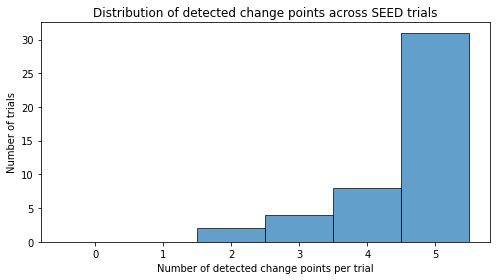


Estimated optimal number of change points per trial ≈ 5


In [13]:
import os
import numpy as np
from collections import defaultdict
from sklearn.covariance import OAS
import scipy.io
import matplotlib.pyplot as plt

# === Configuration ===
fs = 200  # Hz, SEED sampling rate
window_sec = 1
window_samples = fs * window_sec
data_dir = r"C:\Users\jonah\Downloads\Emotions\SEED\Preprocessed_EEG"

# SEED emotion labels (fixed order across trials)
seed_labels = [1, 0, -1, -1, 0, 1, -1, 0, 1, 1, 0, -1, 0, 1, -1]
label_map = {1: "Positive", 0: "Neutral", -1: "Negative"}

# === Helper functions ===

def compute_covariance_oas(X):
    """Compute robust covariance (OAS) for EEG window."""
    oas = OAS()
    oas.fit(X.T)
    cov = oas.covariance_
    cov += 1e-6 * np.eye(cov.shape[0])  # stability
    return cov

def extract_cov_features(eeg_trial, window_samples):
    """Extract upper-triangular covariance features for each 1s window."""
    n_channels, n_samples = eeg_trial.shape
    n_windows = n_samples // window_samples
    features = []
    for w in range(n_windows):
        start = w * window_samples
        end = start + window_samples
        segment = eeg_trial[:, start:end]
        cov = compute_covariance_oas(segment)
        iu = np.triu_indices(n_channels)
        features.append(cov[iu])
    return np.array(features)

def find_change_points(features, threshold_std=2.0, max_points=6):
    """Detect significant feature-change points using threshold on ΔF."""
    if len(features) < 2:
        return np.array([])

    distances = np.linalg.norm(np.diff(features, axis=0), axis=1)
    threshold = np.mean(distances) + threshold_std * np.std(distances)
    change_idxs = np.where(distances > threshold)[0] + 1
    return change_idxs[:max_points]

# === Main processing ===

emotion_boundaries = defaultdict(list)
change_point_counts = defaultdict(list)

for filename in sorted(os.listdir(data_dir)):
    if not filename.endswith(".mat"):
        continue

    mat_path = os.path.join(data_dir, filename)
    mat_data = scipy.io.loadmat(mat_path)
    trial_keys = [k for k in mat_data.keys() if k.startswith("djc_eeg")]
    trial_keys = sorted(trial_keys, key=lambda x: int(x.replace("djc_eeg", "")))

    for idx, key in enumerate(trial_keys):
        eeg_trial = np.squeeze(mat_data[key])  # shape: (n_channels, n_samples)
        emotion = label_map[seed_labels[idx]]

        features = extract_cov_features(eeg_trial, window_samples)
        change_idxs = find_change_points(features, threshold_std=2.0, max_points=5)

        # Save boundary times and counts
        emotion_boundaries[emotion].extend(change_idxs * window_sec)
        change_point_counts[emotion].append(len(change_idxs))

# === Summary statistics ===
print("Segment boundaries (seconds) for each emotion:")
for emotion, boundaries in emotion_boundaries.items():
    avg_b = np.mean(boundaries) if boundaries else 0
    std_b = np.std(boundaries) if boundaries else 0
    avg_n = np.mean(change_point_counts[emotion])
    print(f"{emotion:8s}: Mean boundary = {avg_b:.2f}s ± {std_b:.2f}s | "
          f"Avg # boundaries = {avg_n:.2f} ({len(change_point_counts[emotion])} trials)")

# === Combine and visualize ===
all_counts = []
all_emotions = []
for emotion, counts in change_point_counts.items():
    all_counts.extend(counts)
    all_emotions.extend([emotion] * len(counts))

# Histogram of number of change points
plt.figure(figsize=(7, 4))
plt.hist(all_counts, bins=np.arange(0, max(all_counts) + 2) - 0.5, edgecolor='black', alpha=0.7)
plt.xlabel("Number of detected change points per trial")
plt.ylabel("Number of trials")
plt.title("Distribution of detected change points across SEED trials")
plt.xticks(range(int(max(all_counts)) + 1))
plt.tight_layout()
plt.show()

# === Optimal number estimation ===
optimal_n = int(np.median(all_counts))
print(f"\nEstimated optimal number of change points per trial ≈ {optimal_n}")

In [11]:
import os
import numpy as np
from collections import defaultdict
from sklearn.covariance import OAS
import scipy.io

# --- Configuration ---
fs = 200  # Hz
window_sec = 1
window_samples = fs * window_sec
data_dir = r"C:\Users\jonah\Downloads\Emotions\SEED\Preprocessed_EEG"

# Emotion labels for SEED
seed_labels = [1, 0, -1, -1, 0, 1, -1, 0, 1, 1, 0, -1, 0, 1, -1]
label_map = {1: "Positive", 0: "Neutral", -1: "Negative"}

# --- Helper functions ---
def compute_covariance_oas(X):
    oas = OAS()
    oas.fit(X.T)
    cov = oas.covariance_
    cov += 1e-6 * np.eye(cov.shape[0])
    return cov

def extract_cov_features(eeg_trial, window_samples):
    """Extract covariance-based EEG features for each 1s window."""
    n_channels, n_samples = eeg_trial.shape
    n_windows = n_samples // window_samples
    features = []
    for w in range(n_windows):
        start = w * window_samples
        end = start + window_samples
        segment = eeg_trial[:, start:end]
        cov = compute_covariance_oas(segment)
        iu = np.triu_indices(n_channels)
        features.append(cov[iu])
    return np.array(features)

def find_multiple_change_points(features, threshold_std=2.0, max_points=5):
    """Find multiple significant change points in features."""
    if len(features) < 2:
        return np.array([])
    
    distances = np.linalg.norm(np.diff(features, axis=0), axis=1)
    threshold = np.mean(distances) + threshold_std * np.std(distances)
    change_idxs = np.where(distances > threshold)[0] + 1  # indices of changes
    return change_idxs[:max_points]  # limit to first few strong ones

# --- Main processing ---
emotion_boundaries = defaultdict(list)

for filename in sorted(os.listdir(data_dir)):
    if not filename.endswith(".mat"):
        continue
    
    mat_path = os.path.join(data_dir, filename)
    mat_data = scipy.io.loadmat(mat_path)
    trial_keys = [k for k in mat_data.keys() if k.startswith("djc_eeg")]
    trial_keys = sorted(trial_keys, key=lambda x: int(x.replace("djc_eeg", "")))
    
    for idx, key in enumerate(trial_keys):
        eeg_trial = np.squeeze(mat_data[key])
        emotion = label_map[seed_labels[idx]]

        features = extract_cov_features(eeg_trial, window_samples)
        change_points = find_multiple_change_points(features, threshold_std=2.0, max_points=5)

        if len(change_points) > 0:
            # store time in seconds for all boundaries in this trial
            emotion_boundaries[emotion].append(change_points * window_sec)

# --- Aggregate across trials ---
print("Average boundary positions (seconds) per emotion:\n")

for emotion, all_boundaries in emotion_boundaries.items():
    all_boundaries = [np.array(b) for b in all_boundaries if len(b) > 0]
    max_points = max(len(b) for b in all_boundaries)
    
    print(f"{emotion}:")
    for i in range(max_points):
        # collect i-th boundary from all trials that have at least i+1 boundaries
        valid_points = [b[i] for b in all_boundaries if len(b) > i]
        if len(valid_points) == 0:
            continue
        avg_b = np.mean(valid_points)
        std_b = np.std(valid_points)
        print(f"  Boundary {i+1}: {avg_b:.2f} ± {std_b:.2f} s ({len(valid_points)} trials)")
    print()

Average boundary positions (seconds) per emotion:

Positive:
  Boundary 1: 68.67 ± 57.18 s (15 trials)
  Boundary 2: 76.13 ± 67.32 s (15 trials)
  Boundary 3: 78.50 ± 60.03 s (14 trials)

Neutral:
  Boundary 1: 35.87 ± 34.83 s (15 trials)
  Boundary 2: 52.53 ± 49.45 s (15 trials)
  Boundary 3: 82.71 ± 57.13 s (14 trials)

Negative:
  Boundary 1: 64.20 ± 60.92 s (15 trials)
  Boundary 2: 69.13 ± 60.47 s (15 trials)
  Boundary 3: 100.27 ± 70.44 s (15 trials)



Average boundary positions (seconds) per emotion:

Positive:
  Boundary 1: 83.67 ± 61.45 s (15 trials)
  Boundary 2: 121.47 ± 72.47 s (15 trials)
  Boundary 3: 137.60 ± 75.28 s (15 trials)

Neutral:
  Boundary 1: 48.93 ± 46.53 s (15 trials)
  Boundary 2: 98.53 ± 52.91 s (15 trials)
  Boundary 3: 146.07 ± 58.42 s (15 trials)

Negative:
  Boundary 1: 84.67 ± 78.25 s (15 trials)
  Boundary 2: 120.87 ± 68.90 s (15 trials)
  Boundary 3: 148.00 ± 57.22 s (15 trials)



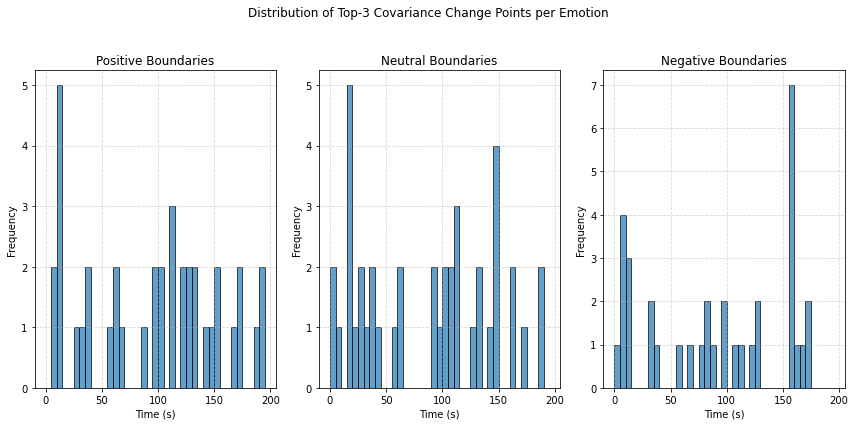

In [12]:
import os
import numpy as np
from collections import defaultdict
from sklearn.covariance import OAS
import scipy.io
import matplotlib.pyplot as plt

# --- Configuration ---
fs = 200  # Hz
window_sec = 1
window_samples = fs * window_sec
data_dir = r"C:\Users\jonah\Downloads\Emotions\SEED\Preprocessed_EEG"

# Emotion labels for SEED
seed_labels = [1, 0, -1, -1, 0, 1, -1, 0, 1, 1, 0, -1, 0, 1, -1]
label_map = {1: "Positive", 0: "Neutral", -1: "Negative"}

# --- Helper functions ---
def compute_covariance_oas(X):
    """Compute stable covariance using OAS shrinkage."""
    oas = OAS()
    oas.fit(X.T)
    cov = oas.covariance_
    cov += 1e-6 * np.eye(cov.shape[0])
    return cov

def extract_cov_features(eeg_trial, window_samples):
    """Extract covariance-based EEG features for each 1-second window."""
    n_channels, n_samples = eeg_trial.shape
    n_windows = n_samples // window_samples
    features = []
    for w in range(n_windows):
        start = w * window_samples
        end = start + window_samples
        segment = eeg_trial[:, start:end]
        cov = compute_covariance_oas(segment)
        iu = np.triu_indices(n_channels)
        features.append(cov[iu])
    return np.array(features)

def find_top_change_points(features, max_points=3):
    """
    Find up to `max_points` strongest change points by largest 
    distance between consecutive covariance feature vectors.
    """
    if len(features) < 2:
        return np.array([])

    distances = np.linalg.norm(np.diff(features, axis=0), axis=1)

    # Sort distances descending and take top-N indices
    top_indices = np.argsort(distances)[::-1][:max_points]

    # Convert to boundary indices (next segment start)
    change_idxs = np.sort(top_indices + 1)
    return change_idxs

# --- Main processing ---
emotion_boundaries = defaultdict(list)

for filename in sorted(os.listdir(data_dir)):
    if not filename.endswith(".mat"):
        continue

    mat_path = os.path.join(data_dir, filename)
    mat_data = scipy.io.loadmat(mat_path)
    trial_keys = [k for k in mat_data.keys() if k.startswith("djc_eeg")]
    trial_keys = sorted(trial_keys, key=lambda x: int(x.replace("djc_eeg", "")))

    for idx, key in enumerate(trial_keys):
        eeg_trial = np.squeeze(mat_data[key])
        emotion = label_map[seed_labels[idx]]

        # Compute covariance-based features
        features = extract_cov_features(eeg_trial, window_samples)

        # Find top 3 strongest change points
        change_points = find_top_change_points(features, max_points=3)

        if len(change_points) > 0:
            # Store boundary times in seconds
            emotion_boundaries[emotion].append(change_points * window_sec)

# --- Aggregate across trials ---
print("Average boundary positions (seconds) per emotion:\n")

for emotion, all_boundaries in emotion_boundaries.items():
    all_boundaries = [np.array(b) for b in all_boundaries if len(b) > 0]
    max_points = max(len(b) for b in all_boundaries)

    print(f"{emotion}:")
    for i in range(max_points):
        valid_points = [b[i] for b in all_boundaries if len(b) > i]
        if len(valid_points) == 0:
            continue
        avg_b = np.mean(valid_points)
        std_b = np.std(valid_points)
        print(f"  Boundary {i+1}: {avg_b:.2f} ± {std_b:.2f} s ({len(valid_points)} trials)")
    print()

# --- Plot histograms of boundary distributions ---
plt.figure(figsize=(12, 6))
bins = np.arange(0, 200, 5)  # 5-second bins up to ~200s

for i, (emotion, all_boundaries) in enumerate(emotion_boundaries.items(), 1):
    plt.subplot(1, 3, i)
    flat_bounds = np.concatenate(all_boundaries)
    plt.hist(flat_bounds, bins=bins, alpha=0.7, edgecolor='black')
    plt.title(f"{emotion} Boundaries")
    plt.xlabel("Time (s)")
    plt.ylabel("Frequency")
    plt.grid(True, linestyle="--", alpha=0.5)

plt.suptitle("Distribution of Top-3 Covariance Change Points per Emotion")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [13]:
import re
import os
import pickle
import numpy as np
import scipy.io
from sklearn.covariance import OAS
from scipy.linalg import logm

# -----------------------------------------------------------
# Configuration
# -----------------------------------------------------------
fs = 200  # Hz
data_dir = r"C:\Users\jonah\Downloads\Emotions\SEED\Preprocessed_EEG"
output_path = "seed_heart_features_multi.pkl"

# SEED emotion mapping and average boundaries (from your summary)
seed_labels = [1, 0, -1, -1, 0, 1, -1, 0, 1, 1, 0, -1, 0, 1, -1]
label_map = {1: "Positive", 0: "Neutral", -1: "Negative"}

emotion_mean_boundaries = {
    "Positive": [83.67, 121.47, 137.60],
    "Neutral":  [48.93, 98.53, 146.07],
    "Negative": [84.67, 120.87, 148.00]
}

# -----------------------------------------------------------
# Utility functions
# -----------------------------------------------------------
def compute_covariance(X):
    """Compute OAS covariance matrix for stability."""
    oas = OAS()
    oas.fit(X.T)
    cov = oas.covariance_
    cov += 1e-6 * np.eye(cov.shape[0])
    return cov

def geodesic_distance(C1, C2):
    """Compute Riemannian (geodesic) distance between covariance matrices."""
    sqrt_C1 = np.linalg.cholesky(C1)
    inv_sqrt_C1 = np.linalg.inv(sqrt_C1)
    C2_norm = inv_sqrt_C1 @ C2 @ inv_sqrt_C1.T
    log_C2_norm = logm(C2_norm)
    return np.linalg.norm(log_C2_norm, 'fro')

def tangent_space_features(C, ref=None):
    """Project covariance matrix to tangent space at ref (identity default)."""
    if ref is None:
        ref = np.eye(C.shape[0])
    logm_diff = logm(np.linalg.inv(ref) @ C)
    iu = np.triu_indices_from(logm_diff)
    return np.real(logm_diff[iu])

def extract_multi_boundary_features(eeg_trial, boundaries_sec):
    """
    Split EEG into multiple segments using boundary times (in seconds),
    compute covariance matrices, distances, speeds, and tangent features.
    """
    n_samples = eeg_trial.shape[1]
    total_time = n_samples / fs

    # Clip and sort boundaries
    boundaries = sorted([b for b in boundaries_sec if b < total_time])
    segment_points = [0] + [int(b * fs) for b in boundaries] + [n_samples]

    covs = []
    for i in range(len(segment_points) - 1):
        start, end = segment_points[i], segment_points[i + 1]
        segment = eeg_trial[:, start:end]
        covs.append(compute_covariance(segment))

    distances, speeds = [], []
    for i in range(len(covs) - 1):
        d = geodesic_distance(covs[i], covs[i + 1])
        dt = (segment_points[i + 1] - segment_points[i]) / fs
        speeds.append(d / dt if dt > 0 else 0)
        distances.append(d)

    # Compute curvature (optional)
    curvature = np.gradient(distances) if len(distances) > 2 else [0] * len(distances)

    # Tangent space features
    tangent_features = [tangent_space_features(C) for C in covs]

    # Concatenate everything into one feature vector
    features = np.concatenate([
        *tangent_features,
        distances,
        speeds,
        curvature
    ])
    return features

# -----------------------------------------------------------
# Main processing
# -----------------------------------------------------------
X, y, subjects = [], [], []
mat_files = [f for f in os.listdir(data_dir) if f.endswith(".mat")]
print(f"Found {len(mat_files)} .mat files\n")

for filename in sorted(mat_files):
    subject_id = filename.split("_")[0]
    mat_path = os.path.join(data_dir, filename)

    try:
        mat_data = scipy.io.loadmat(mat_path, simplify_cells=True)
    except TypeError:
        mat_data = scipy.io.loadmat(mat_path)

    trial_keys = [k for k in mat_data.keys() if re.match(r".*eeg\d+$", k)]
    if not trial_keys:
        print(f"No EEG-like trial keys found in {filename}, skipping.")
        continue

    trial_keys = sorted(trial_keys, key=lambda x: int(re.findall(r"\d+$", x)[0]))
    print(f"Processing {filename}: {len(trial_keys)} trials")

    for idx, key in enumerate(trial_keys):
        if idx >= len(seed_labels):
            continue

        eeg_trial = np.squeeze(np.array(mat_data[key]))
        if eeg_trial.ndim != 2:
            print(f"  Skipping {filename} {key} (shape={eeg_trial.shape})")
            continue

        emotion = label_map[seed_labels[idx]]
        boundaries = emotion_mean_boundaries[emotion]

        try:
            features = extract_multi_boundary_features(eeg_trial, boundaries)
            X.append(features)
            y.append(emotion)
            subjects.append(subject_id)
        except Exception as e:
            print(f"  Error processing {filename} {key}: {e}")
            continue

# -----------------------------------------------------------
# Save features
# -----------------------------------------------------------
with open(output_path, "wb") as f:
    pickle.dump({"features": X, "labels": y, "subjects": subjects}, f)

subject_counts = {s: subjects.count(s) for s in sorted(set(subjects))}
print(f"\nSaved {len(X)} feature vectors to {output_path}")
print(f"Unique subjects: {len(subject_counts)} → {list(subject_counts.keys())}")
for subj, count in subject_counts.items():
    print(f"  Subject {subj}: {count} trials")

Found 46 .mat files

Processing 10_20131130.mat: 15 trials
Processing 10_20131204.mat: 15 trials
Processing 10_20131211.mat: 15 trials
Processing 11_20140618.mat: 15 trials
Processing 11_20140625.mat: 15 trials
Processing 11_20140630.mat: 15 trials
Processing 12_20131127.mat: 15 trials
Processing 12_20131201.mat: 15 trials
Processing 12_20131207.mat: 15 trials
Processing 13_20140527.mat: 15 trials
Processing 13_20140603.mat: 15 trials
Processing 13_20140610.mat: 15 trials
Processing 14_20140601.mat: 15 trials
Processing 14_20140615.mat: 15 trials
Processing 14_20140627.mat: 15 trials
Processing 15_20130709.mat: 15 trials
Processing 15_20131016.mat: 15 trials
Processing 15_20131105.mat: 15 trials
Processing 1_20131027.mat: 15 trials
Processing 1_20131030.mat: 15 trials
Processing 1_20131107.mat: 15 trials
Processing 2_20140404.mat: 15 trials
Processing 2_20140413.mat: 15 trials
Processing 2_20140419.mat: 15 trials
Processing 3_20140603.mat: 15 trials
Processing 3_20140611.mat: 15 trials

In [22]:
import re
import os
import pickle
import numpy as np
import scipy.io
from sklearn.covariance import OAS
from scipy.linalg import logm

# -----------------------------------------------------------
# Configuration
# -----------------------------------------------------------
fs = 200  # Hz
data_dir = r"C:\Users\jonah\Downloads\Emotions\SEED\Preprocessed_EEG"
output_path = "seed_heart_features_multi.pkl"

# SEED emotion mapping and average boundaries (from your summary)
seed_labels = [1, 0, -1, -1, 0, 1, -1, 0, 1, 1, 0, -1, 0, 1, -1]
label_map = {1: "Positive", 0: "Neutral", -1: "Negative"}

emotion_mean_boundaries = {
    "Positive": [68.67, 76.13, 78.50, 97.23, 109.45],
    "Neutral":  [35.87, 52.53, 82.71, 111.54, 123.11],
    "Negative": [64.20, 69.13, 100.27, 127.23, 135.45]
}

# -----------------------------------------------------------
# Utility functions
# -----------------------------------------------------------
def compute_covariance(X):
    """Compute OAS covariance matrix for stability."""
    oas = OAS()
    oas.fit(X.T)
    cov = oas.covariance_
    cov += 1e-6 * np.eye(cov.shape[0])
    return cov

def geodesic_distance(C1, C2):
    """Compute Riemannian (geodesic) distance between covariance matrices."""
    sqrt_C1 = np.linalg.cholesky(C1)
    inv_sqrt_C1 = np.linalg.inv(sqrt_C1)
    C2_norm = inv_sqrt_C1 @ C2 @ inv_sqrt_C1.T
    log_C2_norm = logm(C2_norm)
    return np.linalg.norm(log_C2_norm, 'fro')

def tangent_space_features(C, ref=None):
    """Project covariance matrix to tangent space at ref (identity default)."""
    if ref is None:
        ref = np.eye(C.shape[0])
    logm_diff = logm(np.linalg.inv(ref) @ C)
    iu = np.triu_indices_from(logm_diff)
    return np.real(logm_diff[iu])

def extract_multi_boundary_features(eeg_trial, boundaries_sec):
    """
    Split EEG into multiple segments using boundary times (in seconds),
    compute covariance matrices, distances, speeds, and tangent features.
    """
    n_samples = eeg_trial.shape[1]
    total_time = n_samples / fs

    # Clip and sort boundaries
    boundaries = sorted([b for b in boundaries_sec if b < total_time])
    segment_points = [0] + [int(b * fs) for b in boundaries] + [n_samples]

    covs = []
    for i in range(len(segment_points) - 1):
        start, end = segment_points[i], segment_points[i + 1]
        segment = eeg_trial[:, start:end]
        covs.append(compute_covariance(segment))

    distances, speeds = [], []
    for i in range(len(covs) - 1):
        d = geodesic_distance(covs[i], covs[i + 1])
        dt = (segment_points[i + 1] - segment_points[i]) / fs
        speeds.append(d / dt if dt > 0 else 0)
        distances.append(d)

    # Compute curvature (optional)
    curvature = np.gradient(distances) if len(distances) > 2 else [0] * len(distances)

    # Tangent space features
    tangent_features = [tangent_space_features(C) for C in covs]

    # Concatenate everything into one feature vector
    features = np.concatenate([
        *tangent_features,
        distances,
        speeds,
        curvature
    ])
    return features

# -----------------------------------------------------------
# Main processing
# -----------------------------------------------------------
X, y, subjects = [], [], []
mat_files = [f for f in os.listdir(data_dir) if f.endswith(".mat")]
print(f"Found {len(mat_files)} .mat files\n")

for filename in sorted(mat_files):
    subject_id = filename.split("_")[0]
    mat_path = os.path.join(data_dir, filename)

    try:
        mat_data = scipy.io.loadmat(mat_path, simplify_cells=True)
    except TypeError:
        mat_data = scipy.io.loadmat(mat_path)

    trial_keys = [k for k in mat_data.keys() if re.match(r".*eeg\d+$", k)]
    if not trial_keys:
        print(f"No EEG-like trial keys found in {filename}, skipping.")
        continue

    trial_keys = sorted(trial_keys, key=lambda x: int(re.findall(r"\d+$", x)[0]))
    print(f"Processing {filename}: {len(trial_keys)} trials")

    for idx, key in enumerate(trial_keys):
        if idx >= len(seed_labels):
            continue

        eeg_trial = np.squeeze(np.array(mat_data[key]))
        if eeg_trial.ndim != 2:
            print(f"  Skipping {filename} {key} (shape={eeg_trial.shape})")
            continue

        emotion = label_map[seed_labels[idx]]
        boundaries = emotion_mean_boundaries[emotion]

        try:
            features = extract_multi_boundary_features(eeg_trial, boundaries)
            X.append(features)
            y.append(emotion)
            subjects.append(subject_id)
        except Exception as e:
            print(f"  Error processing {filename} {key}: {e}")
            continue

# -----------------------------------------------------------
# Save features
# -----------------------------------------------------------
with open(output_path, "wb") as f:
    pickle.dump({"features": X, "labels": y, "subjects": subjects}, f)

subject_counts = {s: subjects.count(s) for s in sorted(set(subjects))}
print(f"\nSaved {len(X)} feature vectors to {output_path}")
print(f"Unique subjects: {len(subject_counts)} → {list(subject_counts.keys())}")
for subj, count in subject_counts.items():
    print(f"  Subject {subj}: {count} trials")

Found 46 .mat files

Processing 10_20131130.mat: 15 trials
Processing 10_20131204.mat: 15 trials


KeyboardInterrupt: 

Training subjects: ['8' '14' '3' '11' '10' '9' '13' '2' '5' '7' '12' '15']
Testing subjects : ['4' '6' '1']
Train samples: 540, Test samples: 135

Classification Report (subject-independent test):

              precision    recall  f1-score   support

    Negative       0.83      0.96      0.89        45
     Neutral       0.92      0.78      0.84        45
    Positive       0.96      0.96      0.96        45

    accuracy                           0.90       135
   macro avg       0.90      0.90      0.90       135
weighted avg       0.90      0.90      0.90       135



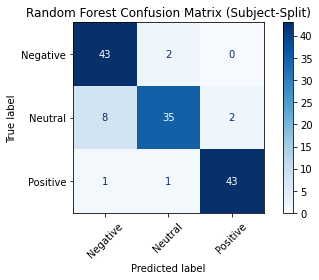

In [3]:
import pickle
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# --------------------------------------------------------
# Load SEED features
# --------------------------------------------------------
with open("seed_heart_features_multi.pkl", "rb") as f:
    data = pickle.load(f)

X = np.array(data["features"])
y = np.array(data["labels"])
subjects = np.array(data["subjects"])

# Encode emotion labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# --------------------------------------------------------
# Split by subject (no leakage)
# --------------------------------------------------------
unique_subjects = np.unique(subjects)
train_subj, test_subj = train_test_split(
    unique_subjects, test_size=0.2, random_state=42
)

train_mask = np.isin(subjects, train_subj)
test_mask = np.isin(subjects, test_subj)

X_train, X_test = X[train_mask], X[test_mask]
y_train, y_test = y_encoded[train_mask], y_encoded[test_mask]

print(f"Training subjects: {train_subj}")
print(f"Testing subjects : {test_subj}")
print(f"Train samples: {len(X_train)}, Test samples: {len(X_test)}")

# --------------------------------------------------------
# Train Random Forest
# --------------------------------------------------------
clf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
clf.fit(X_train, y_train)

# --------------------------------------------------------
# Evaluate
# --------------------------------------------------------
y_pred = clf.predict(X_test)

print("\nClassification Report (subject-independent test):\n")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Random Forest Confusion Matrix (Subject-Split)")
plt.tight_layout()
plt.show()

In [23]:
import pickle
import numpy as np

# --------------------------------------------------------
# Load SEED feature data
# --------------------------------------------------------
with open("seed_heart_features_multi.pkl", "rb") as f:
    data = pickle.load(f)

X = data["features"]
y = data["labels"]
subjects = data["subjects"]

# --------------------------------------------------------
# Russell’s Circumplex Model for SEED emotion categories
# --------------------------------------------------------
# Representative VAD (Valence–Arousal–Dominance) coordinates
# Based on typical affective mapping:
#   Positive ≈ Joy (high valence, high arousal, high dominance)
#   Neutral  ≈ Neutral (mid valence, mid arousal, mid dominance)
#   Negative ≈ Sadness (low valence, low arousal, low dominance)
emotion_to_vad = {
    "Positive": [0.9, 0.9, 0.8],
    "Neutral":  [0.5, 0.5, 0.5],
    "Negative": [0.1, 0.2, 0.3]
}

# --------------------------------------------------------
# Build VAD arrays
# --------------------------------------------------------
V, A, D = [], [], []

for emotion in y:
    valence, arousal, dominance = emotion_to_vad.get(emotion, [0.5, 0.5, 0.5])
    V.append(valence)
    A.append(arousal)
    D.append(dominance)

V, A, D = np.array(V), np.array(A), np.array(D)

# --------------------------------------------------------
# Save augmented data
# --------------------------------------------------------
augmented_data = {
    "features": X,
    "labels": y,
    "subjects": subjects,
    "valence": V,
    "arousal": A,
    "dominance": D,
}

output_path = "seed_heart_features_multi_with_vad.pkl"
with open(output_path, "wb") as f:
    pickle.dump(augmented_data, f)

print(f"Saved SEED augmented data with VAD to {output_path}")
print(f"Total samples: {len(X)} | Unique emotions: {set(y)}")

Saved SEED augmented data with VAD to seed_heart_features_multi_with_vad.pkl
Total samples: 675 | Unique emotions: {'Positive', 'Neutral', 'Negative'}


In [9]:
import pickle
import numpy as np
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, GroupKFold
from sklearn.metrics import classification_report

# --------------------------------------------------------
# Load SEED preprocessed feature data
# --------------------------------------------------------
with open("seed_heart_features_multi_with_vad.pkl", "rb") as f:
    data = pickle.load(f)

X = np.array(data["features"])
V = np.array(data["valence"])
A = np.array(data["arousal"])
D = np.array(data["dominance"])
labels = np.array(data["labels"])
subjects = np.array(data["subjects"])

# --------------------------------------------------------
# Encode emotions
# --------------------------------------------------------
le = LabelEncoder()
y = le.fit_transform(labels)
n_classes = len(le.classes_)
print(f"Loaded {len(X)} samples from {len(np.unique(subjects))} subjects.")

# --------------------------------------------------------
# Subject-wise 80/20 split
# --------------------------------------------------------
unique_subjects = np.unique(subjects)
train_subjects, test_subjects = train_test_split(
    unique_subjects, test_size=0.2, random_state=42
)
train_mask = np.isin(subjects, train_subjects)
test_mask = np.isin(subjects, test_subjects)

X_train, X_test = X[train_mask], X[test_mask]
y_train, y_test = y[train_mask], y[test_mask]
V_train, V_test = V[train_mask], V[test_mask]
A_train, A_test = A[train_mask], A[test_mask]
D_train, D_test = D[train_mask], D[test_mask]
subjects_train = subjects[train_mask]

print(f"Train subjects: {train_subjects}")
print(f"Test subjects : {test_subjects}")
print(f"Train samples: {len(X_train)}, Test samples: {len(X_test)}")

# --------------------------------------------------------
# Prepare meta-features via GroupKFold (subject-aware CV)
# --------------------------------------------------------
meta_train = np.zeros((X_train.shape[0], 3 + n_classes))  # [V, A, D] + emotion probs

gkf = GroupKFold(n_splits=5)
fold = 1
for train_idx, val_idx in gkf.split(X_train, y_train, groups=subjects_train):
    print(f"  Fold {fold}: training {len(train_idx)}, validating {len(val_idx)}")
    fold += 1

    X_fold_train, X_fold_val = X_train[train_idx], X_train[val_idx]
    y_fold_train, y_fold_val = y_train[train_idx], y_train[val_idx]
    V_fold_train, V_fold_val = V_train[train_idx], V_train[val_idx]
    A_fold_train, A_fold_val = A_train[train_idx], A_train[val_idx]
    D_fold_train, D_fold_val = D_train[train_idx], D_train[val_idx]

    # Base regressors + classifier
    reg_V = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
    reg_A = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
    reg_D = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
    clf_emotion = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)

    reg_V.fit(X_fold_train, V_fold_train)
    reg_A.fit(X_fold_train, A_fold_train)
    reg_D.fit(X_fold_train, D_fold_train)
    clf_emotion.fit(X_fold_train, y_fold_train)

    # Validation predictions for meta-training
    V_pred = reg_V.predict(X_fold_val).reshape(-1, 1)
    A_pred = reg_A.predict(X_fold_val).reshape(-1, 1)
    D_pred = reg_D.predict(X_fold_val).reshape(-1, 1)
    probs = clf_emotion.predict_proba(X_fold_val)

    meta_train[val_idx] = np.hstack([V_pred, A_pred, D_pred, probs])

# --------------------------------------------------------
# Train final base models on full training set
# --------------------------------------------------------
reg_V_final = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
reg_A_final = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
reg_D_final = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
clf_emotion_final = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)

reg_V_final.fit(X_train, V_train)
reg_A_final.fit(X_train, A_train)
reg_D_final.fit(X_train, D_train)
clf_emotion_final.fit(X_train, y_train)

# Test predictions for meta-testing
V_pred_test = reg_V_final.predict(X_test).reshape(-1, 1)
A_pred_test = reg_A_final.predict(X_test).reshape(-1, 1)
D_pred_test = reg_D_final.predict(X_test).reshape(-1, 1)
probs_test = clf_emotion_final.predict_proba(X_test)
meta_test = np.hstack([V_pred_test, A_pred_test, D_pred_test, probs_test])

# --------------------------------------------------------
# Train and evaluate meta-classifier
# --------------------------------------------------------
meta_clf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
meta_clf.fit(meta_train, y_train)
y_pred_meta = meta_clf.predict(meta_test)

print("\n=== Meta-Classifier Performance (Subject-wise Split) ===\n")
print(classification_report(y_test, y_pred_meta, target_names=le.classes_, digits=3))

Loaded 675 samples from 15 subjects.
Train subjects: ['8' '14' '3' '11' '10' '9' '13' '2' '5' '7' '12' '15']
Test subjects : ['4' '6' '1']
Train samples: 540, Test samples: 135
  Fold 1: training 405, validating 135
  Fold 2: training 405, validating 135
  Fold 3: training 450, validating 90
  Fold 4: training 450, validating 90
  Fold 5: training 450, validating 90

=== Meta-Classifier Performance (Subject-wise Split) ===

              precision    recall  f1-score   support

    Negative      1.000     1.000     1.000        45
     Neutral      1.000     1.000     1.000        45
    Positive      1.000     1.000     1.000        45

    accuracy                          1.000       135
   macro avg      1.000     1.000     1.000       135
weighted avg      1.000     1.000     1.000       135



### Channel reduction

In [8]:
import re
import os
import pickle
import numpy as np
import scipy.io
from sklearn.covariance import OAS
from scipy.linalg import logm

# -----------------------------------------------------------
# Configuration
# -----------------------------------------------------------
fs = 200  # Hz
data_dir = r"C:\Users\jonah\Downloads\Emotions\SEED\Preprocessed_EEG"
output_path = "seed_heart_features_multi_20_ch.pkl"

# Full SEED official channel order (62 channels)
SEED_CHANNELS = [
    "Fp1","Fpz","Fp2","AF3","AF4","F7","F5","F3","F1","Fz","F2","F4","F6","F8",
    "FT7","FC5","FC3","FC1","FCz","FC2","FC4","FC6","FT8","T7","C5","C3","C1","Cz","C2",
    "C4","C6","T8","TP7","CP5","CP3","CP1","CPz","CP2","CP4","CP6","TP8","P7","P5","P3",
    "P1","Pz","P2","P4","P6","P8","PO7","PO5","PO3","POz","PO4","PO6","PO8","CB1","O1","Oz","O2","CB2"
]

# Select only these 20 channels
SELECTED_CHANNELS = [
    "Fp1","Fp2","Fz","F3","F4","F7","F8",
    "FC1","FC2","FC5","FC6",
    "Cz","C3","C4","T7","T8",
    "P7","P8","O1","O2"
]

selected_indices = [SEED_CHANNELS.index(ch) for ch in SELECTED_CHANNELS]

# -----------------------------------------------------------
# SEED emotion mapping + boundaries
# -----------------------------------------------------------
seed_labels = [1, 0, -1, -1, 0, 1, -1, 0, 1, 1, 0, -1, 0, 1, -1]
label_map = {1: "Positive", 0: "Neutral", -1: "Negative"}

emotion_mean_boundaries = {
    "Positive": [68.67, 76.13, 78.50, 97.23, 109.45],
    "Neutral":  [35.87, 52.53, 82.71, 111.54, 123.11],
    "Negative": [64.20, 69.13, 100.27, 127.23, 135.45]
}

# -----------------------------------------------------------
# Utility functions
# -----------------------------------------------------------
def compute_covariance(X):
    oas = OAS()
    oas.fit(X.T)
    cov = oas.covariance_
    cov += 1e-6 * np.eye(cov.shape[0])
    return cov

def geodesic_distance(C1, C2):
    sqrt_C1 = np.linalg.cholesky(C1)
    inv_sqrt_C1 = np.linalg.inv(sqrt_C1)
    C2_norm = inv_sqrt_C1 @ C2 @ inv_sqrt_C1.T
    log_C2_norm = logm(C2_norm)
    return np.linalg.norm(np.real(log_C2_norm), 'fro')

def tangent_space_features(C, ref=None):
    if ref is None:
        ref = np.eye(C.shape[0])
    logm_diff = logm(np.linalg.inv(ref) @ C)
    iu = np.triu_indices_from(logm_diff)
    return np.real(logm_diff[iu])

def extract_multi_boundary_features(eeg_trial, boundaries_sec):
    n_samples = eeg_trial.shape[1]
    total_time = n_samples / fs

    boundaries = sorted([b for b in boundaries_sec if b < total_time])
    segment_points = [0] + [int(b * fs) for b in boundaries] + [n_samples]

    covs = []
    for i in range(len(segment_points) - 1):
        start, end = segment_points[i], segment_points[i + 1]
        segment = eeg_trial[:, start:end]
        covs.append(compute_covariance(segment))

    distances, speeds = [], []
    for i in range(len(covs) - 1):
        d = geodesic_distance(covs[i], covs[i + 1])
        dt = (segment_points[i + 1] - segment_points[i]) / fs
        speeds.append(d / dt if dt > 0 else 0)
        distances.append(d)

    curvature = np.gradient(distances) if len(distances) > 2 else [0] * len(distances)
    tangent_features = [tangent_space_features(C) for C in covs]

    return np.concatenate([*tangent_features, distances, speeds, curvature])

# -----------------------------------------------------------
# Main processing
# -----------------------------------------------------------
X, y, subjects = [], [], []
mat_files = [f for f in os.listdir(data_dir) if f.endswith(".mat")]
print(f"Found {len(mat_files)} .mat files\n")

for filename in sorted(mat_files):
    subject_id = filename.split("_")[0]
    mat_path = os.path.join(data_dir, filename)

    mat_data = scipy.io.loadmat(mat_path, simplify_cells=True)

    # trial keys format: djc_eeg1 ... djc_eeg15
    trial_keys = [k for k in mat_data.keys() if re.match(r".*eeg\d+$", k)]
    trial_keys = sorted(trial_keys, key=lambda x: int(re.findall(r"\d+$", x)[0]))

    print(f"Processing {filename}: {len(trial_keys)} trials")

    for idx, key in enumerate(trial_keys):
        if idx >= len(seed_labels):
            continue

        eeg_trial = np.squeeze(np.array(mat_data[key]))
        if eeg_trial.ndim != 2:
            print(f"  Skipping {filename} {key} (shape={eeg_trial.shape})")
            continue

        # Select only desired channels
        eeg_trial = eeg_trial[selected_indices, :]

        emotion = label_map[seed_labels[idx]]
        boundaries = emotion_mean_boundaries[emotion]

        try:
            feat = extract_multi_boundary_features(eeg_trial, boundaries)
            X.append(feat)
            y.append(emotion)
            subjects.append(subject_id)
        except Exception as e:
            print(f"  Error {filename} {key}: {e}")
            continue

# -----------------------------------------------------------
# Save
# -----------------------------------------------------------
with open(output_path, "wb") as f:
    pickle.dump({"features": X, "labels": y, "subjects": subjects}, f)

subject_counts = {s: subjects.count(s) for s in sorted(set(subjects))}
print(f"\nSaved {len(X)} feature vectors to {output_path}")
print(f"Unique subjects: {len(subject_counts)} → {list(subject_counts.keys())}")
for subj, count in subject_counts.items():
    print(f"  Subject {subj}: {count} trials")

Found 46 .mat files

Processing 10_20131130.mat: 15 trials
Processing 10_20131204.mat: 15 trials
Processing 10_20131211.mat: 15 trials
Processing 11_20140618.mat: 15 trials
Processing 11_20140625.mat: 15 trials
Processing 11_20140630.mat: 15 trials
Processing 12_20131127.mat: 15 trials
Processing 12_20131201.mat: 15 trials
Processing 12_20131207.mat: 15 trials
Processing 13_20140527.mat: 15 trials
Processing 13_20140603.mat: 15 trials
Processing 13_20140610.mat: 15 trials
Processing 14_20140601.mat: 15 trials
Processing 14_20140615.mat: 15 trials
Processing 14_20140627.mat: 15 trials
Processing 15_20130709.mat: 15 trials
Processing 15_20131016.mat: 15 trials
Processing 15_20131105.mat: 15 trials
Processing 1_20131027.mat: 15 trials
Processing 1_20131030.mat: 15 trials
Processing 1_20131107.mat: 15 trials
Processing 2_20140404.mat: 15 trials
Processing 2_20140413.mat: 15 trials
Processing 2_20140419.mat: 15 trials
Processing 3_20140603.mat: 15 trials
Processing 3_20140611.mat: 15 trials

In [10]:
import pickle
import numpy as np

# --------------------------------------------------------
# Load SEED feature data
# --------------------------------------------------------
with open("seed_heart_features_multi_20_ch.pkl", "rb") as f:
    data = pickle.load(f)

X = data["features"]
y = data["labels"]
subjects = data["subjects"]

# --------------------------------------------------------
# Russell’s Circumplex Model for SEED emotion categories
# --------------------------------------------------------
# Representative VAD (Valence–Arousal–Dominance) coordinates
# Based on typical affective mapping:
#   Positive ≈ Joy (high valence, high arousal, high dominance)
#   Neutral  ≈ Neutral (mid valence, mid arousal, mid dominance)
#   Negative ≈ Sadness (low valence, low arousal, low dominance)
emotion_to_vad = {
    "Positive": [0.9, 0.9, 0.8],
    "Neutral":  [0.5, 0.5, 0.5],
    "Negative": [0.1, 0.2, 0.3]
}

# --------------------------------------------------------
# Build VAD arrays
# --------------------------------------------------------
V, A, D = [], [], []

for emotion in y:
    valence, arousal, dominance = emotion_to_vad.get(emotion, [0.5, 0.5, 0.5])
    V.append(valence)
    A.append(arousal)
    D.append(dominance)

V, A, D = np.array(V), np.array(A), np.array(D)

# --------------------------------------------------------
# Save augmented data
# --------------------------------------------------------
augmented_data = {
    "features": X,
    "labels": y,
    "subjects": subjects,
    "valence": V,
    "arousal": A,
    "dominance": D,
}

output_path = "seed_heart_features_multi_20_ch_with_vad.pkl"
with open(output_path, "wb") as f:
    pickle.dump(augmented_data, f)

print(f"Saved SEED augmented data with VAD to {output_path}")
print(f"Total samples: {len(X)} | Unique emotions: {set(y)}")

Saved SEED augmented data with VAD to seed_heart_features_multi_20_ch_with_vad.pkl
Total samples: 675 | Unique emotions: {'Positive', 'Neutral', 'Negative'}


In [11]:
import pickle
import numpy as np
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, GroupKFold
from sklearn.metrics import classification_report

# --------------------------------------------------------
# Load SEED preprocessed feature data
# --------------------------------------------------------
with open("seed_heart_features_multi_20_ch_with_vad.pkl", "rb") as f:
    data = pickle.load(f)

X = np.array(data["features"])
V = np.array(data["valence"])
A = np.array(data["arousal"])
D = np.array(data["dominance"])
labels = np.array(data["labels"])
subjects = np.array(data["subjects"])

# --------------------------------------------------------
# Encode emotions
# --------------------------------------------------------
le = LabelEncoder()
y = le.fit_transform(labels)
n_classes = len(le.classes_)
print(f"Loaded {len(X)} samples from {len(np.unique(subjects))} subjects.")

# --------------------------------------------------------
# Subject-wise 80/20 split
# --------------------------------------------------------
unique_subjects = np.unique(subjects)
train_subjects, test_subjects = train_test_split(
    unique_subjects, test_size=0.2, random_state=42
)
train_mask = np.isin(subjects, train_subjects)
test_mask = np.isin(subjects, test_subjects)

X_train, X_test = X[train_mask], X[test_mask]
y_train, y_test = y[train_mask], y[test_mask]
V_train, V_test = V[train_mask], V[test_mask]
A_train, A_test = A[train_mask], A[test_mask]
D_train, D_test = D[train_mask], D[test_mask]
subjects_train = subjects[train_mask]

print(f"Train subjects: {train_subjects}")
print(f"Test subjects : {test_subjects}")
print(f"Train samples: {len(X_train)}, Test samples: {len(X_test)}")

# --------------------------------------------------------
# Prepare meta-features via GroupKFold (subject-aware CV)
# --------------------------------------------------------
meta_train = np.zeros((X_train.shape[0], 3 + n_classes))  # [V, A, D] + emotion probs

gkf = GroupKFold(n_splits=5)
fold = 1
for train_idx, val_idx in gkf.split(X_train, y_train, groups=subjects_train):
    print(f"  Fold {fold}: training {len(train_idx)}, validating {len(val_idx)}")
    fold += 1

    X_fold_train, X_fold_val = X_train[train_idx], X_train[val_idx]
    y_fold_train, y_fold_val = y_train[train_idx], y_train[val_idx]
    V_fold_train, V_fold_val = V_train[train_idx], V_train[val_idx]
    A_fold_train, A_fold_val = A_train[train_idx], A_train[val_idx]
    D_fold_train, D_fold_val = D_train[train_idx], D_train[val_idx]

    # Base regressors + classifier
    reg_V = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
    reg_A = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
    reg_D = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
    clf_emotion = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)

    reg_V.fit(X_fold_train, V_fold_train)
    reg_A.fit(X_fold_train, A_fold_train)
    reg_D.fit(X_fold_train, D_fold_train)
    clf_emotion.fit(X_fold_train, y_fold_train)

    # Validation predictions for meta-training
    V_pred = reg_V.predict(X_fold_val).reshape(-1, 1)
    A_pred = reg_A.predict(X_fold_val).reshape(-1, 1)
    D_pred = reg_D.predict(X_fold_val).reshape(-1, 1)
    probs = clf_emotion.predict_proba(X_fold_val)

    meta_train[val_idx] = np.hstack([V_pred, A_pred, D_pred, probs])

# --------------------------------------------------------
# Train final base models on full training set
# --------------------------------------------------------
reg_V_final = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
reg_A_final = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
reg_D_final = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
clf_emotion_final = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)

reg_V_final.fit(X_train, V_train)
reg_A_final.fit(X_train, A_train)
reg_D_final.fit(X_train, D_train)
clf_emotion_final.fit(X_train, y_train)

# Test predictions for meta-testing
V_pred_test = reg_V_final.predict(X_test).reshape(-1, 1)
A_pred_test = reg_A_final.predict(X_test).reshape(-1, 1)
D_pred_test = reg_D_final.predict(X_test).reshape(-1, 1)
probs_test = clf_emotion_final.predict_proba(X_test)
meta_test = np.hstack([V_pred_test, A_pred_test, D_pred_test, probs_test])

# --------------------------------------------------------
# Train and evaluate meta-classifier
# --------------------------------------------------------
meta_clf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
meta_clf.fit(meta_train, y_train)
y_pred_meta = meta_clf.predict(meta_test)

print("\n=== Meta-Classifier Performance (Subject-wise Split) ===\n")
print(classification_report(y_test, y_pred_meta, target_names=le.classes_, digits=3))

Loaded 675 samples from 15 subjects.
Train subjects: ['8' '14' '3' '11' '10' '9' '13' '2' '5' '7' '12' '15']
Test subjects : ['4' '6' '1']
Train samples: 540, Test samples: 135
  Fold 1: training 405, validating 135
  Fold 2: training 405, validating 135
  Fold 3: training 450, validating 90
  Fold 4: training 450, validating 90
  Fold 5: training 450, validating 90

=== Meta-Classifier Performance (Subject-wise Split) ===

              precision    recall  f1-score   support

    Negative      0.957     1.000     0.978        45
     Neutral      1.000     0.956     0.977        45
    Positive      1.000     1.000     1.000        45

    accuracy                          0.985       135
   macro avg      0.986     0.985     0.985       135
weighted avg      0.986     0.985     0.985       135



In [12]:
import re
import os
import pickle
import numpy as np
import scipy.io
from sklearn.covariance import OAS
from scipy.linalg import logm

# -----------------------------------------------------------
# Configuration
# -----------------------------------------------------------
fs = 200  # Hz
data_dir = r"C:\Users\jonah\Downloads\Emotions\SEED\Preprocessed_EEG"
output_path = "seed_heart_features_multi_8_ch.pkl"

# Full SEED official channel order (62 channels)
SEED_CHANNELS = [
    "Fp1","Fpz","Fp2","AF3","AF4","F7","F5","F3","F1","Fz","F2","F4","F6","F8",
    "FT7","FC5","FC3","FC1","FCz","FC2","FC4","FC6","FT8","T7","C5","C3","C1","Cz","C2",
    "C4","C6","T8","TP7","CP5","CP3","CP1","CPz","CP2","CP4","CP6","TP8","P7","P5","P3",
    "P1","Pz","P2","P4","P6","P8","PO7","PO5","PO3","POz","PO4","PO6","PO8","CB1","O1","Oz","O2","CB2"
]

# Select only these 8 channels
SELECTED_CHANNELS = [
    "Fp1","Fp2","Fz",
    "Cz",
    "P3","P4",
    "O1","O2"
]

selected_indices = [SEED_CHANNELS.index(ch) for ch in SELECTED_CHANNELS]

# -----------------------------------------------------------
# SEED emotion mapping + boundaries
# -----------------------------------------------------------
seed_labels = [1, 0, -1, -1, 0, 1, -1, 0, 1, 1, 0, -1, 0, 1, -1]
label_map = {1: "Positive", 0: "Neutral", -1: "Negative"}

emotion_mean_boundaries = {
    "Positive": [68.67, 76.13, 78.50, 97.23, 109.45],
    "Neutral":  [35.87, 52.53, 82.71, 111.54, 123.11],
    "Negative": [64.20, 69.13, 100.27, 127.23, 135.45]
}

# -----------------------------------------------------------
# Utility functions
# -----------------------------------------------------------
def compute_covariance(X):
    oas = OAS()
    oas.fit(X.T)
    cov = oas.covariance_
    cov += 1e-6 * np.eye(cov.shape[0])
    return cov

def geodesic_distance(C1, C2):
    sqrt_C1 = np.linalg.cholesky(C1)
    inv_sqrt_C1 = np.linalg.inv(sqrt_C1)
    C2_norm = inv_sqrt_C1 @ C2 @ inv_sqrt_C1.T
    log_C2_norm = logm(C2_norm)
    return np.linalg.norm(np.real(log_C2_norm), 'fro')

def tangent_space_features(C, ref=None):
    if ref is None:
        ref = np.eye(C.shape[0])
    logm_diff = logm(np.linalg.inv(ref) @ C)
    iu = np.triu_indices_from(logm_diff)
    return np.real(logm_diff[iu])

def extract_multi_boundary_features(eeg_trial, boundaries_sec):
    n_samples = eeg_trial.shape[1]
    total_time = n_samples / fs

    boundaries = sorted([b for b in boundaries_sec if b < total_time])
    segment_points = [0] + [int(b * fs) for b in boundaries] + [n_samples]

    covs = []
    for i in range(len(segment_points) - 1):
        start, end = segment_points[i], segment_points[i + 1]
        segment = eeg_trial[:, start:end]
        covs.append(compute_covariance(segment))

    distances, speeds = [], []
    for i in range(len(covs) - 1):
        d = geodesic_distance(covs[i], covs[i + 1])
        dt = (segment_points[i + 1] - segment_points[i]) / fs
        speeds.append(d / dt if dt > 0 else 0)
        distances.append(d)

    curvature = np.gradient(distances) if len(distances) > 2 else [0] * len(distances)
    tangent_features = [tangent_space_features(C) for C in covs]

    return np.concatenate([*tangent_features, distances, speeds, curvature])

# -----------------------------------------------------------
# Main processing
# -----------------------------------------------------------
X, y, subjects = [], [], []
mat_files = [f for f in os.listdir(data_dir) if f.endswith(".mat")]
print(f"Found {len(mat_files)} .mat files\n")

for filename in sorted(mat_files):
    subject_id = filename.split("_")[0]
    mat_path = os.path.join(data_dir, filename)

    mat_data = scipy.io.loadmat(mat_path, simplify_cells=True)

    # trial keys format: djc_eeg1 ... djc_eeg15
    trial_keys = [k for k in mat_data.keys() if re.match(r".*eeg\d+$", k)]
    trial_keys = sorted(trial_keys, key=lambda x: int(re.findall(r"\d+$", x)[0]))

    print(f"Processing {filename}: {len(trial_keys)} trials")

    for idx, key in enumerate(trial_keys):
        if idx >= len(seed_labels):
            continue

        eeg_trial = np.squeeze(np.array(mat_data[key]))
        if eeg_trial.ndim != 2:
            print(f"  Skipping {filename} {key} (shape={eeg_trial.shape})")
            continue

        # Select only desired channels
        eeg_trial = eeg_trial[selected_indices, :]

        emotion = label_map[seed_labels[idx]]
        boundaries = emotion_mean_boundaries[emotion]

        try:
            feat = extract_multi_boundary_features(eeg_trial, boundaries)
            X.append(feat)
            y.append(emotion)
            subjects.append(subject_id)
        except Exception as e:
            print(f"  Error {filename} {key}: {e}")
            continue

# -----------------------------------------------------------
# Save
# -----------------------------------------------------------
with open(output_path, "wb") as f:
    pickle.dump({"features": X, "labels": y, "subjects": subjects}, f)

subject_counts = {s: subjects.count(s) for s in sorted(set(subjects))}
print(f"\nSaved {len(X)} feature vectors to {output_path}")
print(f"Unique subjects: {len(subject_counts)} → {list(subject_counts.keys())}")
for subj, count in subject_counts.items():
    print(f"  Subject {subj}: {count} trials")

Found 46 .mat files

Processing 10_20131130.mat: 15 trials
Processing 10_20131204.mat: 15 trials
Processing 10_20131211.mat: 15 trials
Processing 11_20140618.mat: 15 trials
Processing 11_20140625.mat: 15 trials
Processing 11_20140630.mat: 15 trials
Processing 12_20131127.mat: 15 trials
Processing 12_20131201.mat: 15 trials
Processing 12_20131207.mat: 15 trials
Processing 13_20140527.mat: 15 trials
Processing 13_20140603.mat: 15 trials
Processing 13_20140610.mat: 15 trials
Processing 14_20140601.mat: 15 trials
Processing 14_20140615.mat: 15 trials
Processing 14_20140627.mat: 15 trials
Processing 15_20130709.mat: 15 trials
Processing 15_20131016.mat: 15 trials
Processing 15_20131105.mat: 15 trials
Processing 1_20131027.mat: 15 trials
Processing 1_20131030.mat: 15 trials
Processing 1_20131107.mat: 15 trials
Processing 2_20140404.mat: 15 trials
Processing 2_20140413.mat: 15 trials
Processing 2_20140419.mat: 15 trials
Processing 3_20140603.mat: 15 trials
Processing 3_20140611.mat: 15 trials

In [13]:
import pickle
import numpy as np

# --------------------------------------------------------
# Load SEED feature data
# --------------------------------------------------------
with open("seed_heart_features_multi_8_ch.pkl", "rb") as f:
    data = pickle.load(f)

X = data["features"]
y = data["labels"]
subjects = data["subjects"]

# --------------------------------------------------------
# Russell’s Circumplex Model for SEED emotion categories
# --------------------------------------------------------
# Representative VAD (Valence–Arousal–Dominance) coordinates
# Based on typical affective mapping:
#   Positive ≈ Joy (high valence, high arousal, high dominance)
#   Neutral  ≈ Neutral (mid valence, mid arousal, mid dominance)
#   Negative ≈ Sadness (low valence, low arousal, low dominance)
emotion_to_vad = {
    "Positive": [0.9, 0.9, 0.8],
    "Neutral":  [0.5, 0.5, 0.5],
    "Negative": [0.1, 0.2, 0.3]
}

# --------------------------------------------------------
# Build VAD arrays
# --------------------------------------------------------
V, A, D = [], [], []

for emotion in y:
    valence, arousal, dominance = emotion_to_vad.get(emotion, [0.5, 0.5, 0.5])
    V.append(valence)
    A.append(arousal)
    D.append(dominance)

V, A, D = np.array(V), np.array(A), np.array(D)

# --------------------------------------------------------
# Save augmented data
# --------------------------------------------------------
augmented_data = {
    "features": X,
    "labels": y,
    "subjects": subjects,
    "valence": V,
    "arousal": A,
    "dominance": D,
}

output_path = "seed_heart_features_multi_8_ch_with_vad.pkl"
with open(output_path, "wb") as f:
    pickle.dump(augmented_data, f)

print(f"Saved SEED augmented data with VAD to {output_path}")
print(f"Total samples: {len(X)} | Unique emotions: {set(y)}")

Saved SEED augmented data with VAD to seed_heart_features_multi_8_ch_with_vad.pkl
Total samples: 675 | Unique emotions: {'Positive', 'Neutral', 'Negative'}


In [14]:
import pickle
import numpy as np
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, GroupKFold
from sklearn.metrics import classification_report

# --------------------------------------------------------
# Load SEED preprocessed feature data
# --------------------------------------------------------
with open("seed_heart_features_multi_8_ch_with_vad.pkl", "rb") as f:
    data = pickle.load(f)

X = np.array(data["features"])
V = np.array(data["valence"])
A = np.array(data["arousal"])
D = np.array(data["dominance"])
labels = np.array(data["labels"])
subjects = np.array(data["subjects"])

# --------------------------------------------------------
# Encode emotions
# --------------------------------------------------------
le = LabelEncoder()
y = le.fit_transform(labels)
n_classes = len(le.classes_)
print(f"Loaded {len(X)} samples from {len(np.unique(subjects))} subjects.")

# --------------------------------------------------------
# Subject-wise 80/20 split
# --------------------------------------------------------
unique_subjects = np.unique(subjects)
train_subjects, test_subjects = train_test_split(
    unique_subjects, test_size=0.2, random_state=42
)
train_mask = np.isin(subjects, train_subjects)
test_mask = np.isin(subjects, test_subjects)

X_train, X_test = X[train_mask], X[test_mask]
y_train, y_test = y[train_mask], y[test_mask]
V_train, V_test = V[train_mask], V[test_mask]
A_train, A_test = A[train_mask], A[test_mask]
D_train, D_test = D[train_mask], D[test_mask]
subjects_train = subjects[train_mask]

print(f"Train subjects: {train_subjects}")
print(f"Test subjects : {test_subjects}")
print(f"Train samples: {len(X_train)}, Test samples: {len(X_test)}")

# --------------------------------------------------------
# Prepare meta-features via GroupKFold (subject-aware CV)
# --------------------------------------------------------
meta_train = np.zeros((X_train.shape[0], 3 + n_classes))  # [V, A, D] + emotion probs

gkf = GroupKFold(n_splits=5)
fold = 1
for train_idx, val_idx in gkf.split(X_train, y_train, groups=subjects_train):
    print(f"  Fold {fold}: training {len(train_idx)}, validating {len(val_idx)}")
    fold += 1

    X_fold_train, X_fold_val = X_train[train_idx], X_train[val_idx]
    y_fold_train, y_fold_val = y_train[train_idx], y_train[val_idx]
    V_fold_train, V_fold_val = V_train[train_idx], V_train[val_idx]
    A_fold_train, A_fold_val = A_train[train_idx], A_train[val_idx]
    D_fold_train, D_fold_val = D_train[train_idx], D_train[val_idx]

    # Base regressors + classifier
    reg_V = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
    reg_A = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
    reg_D = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
    clf_emotion = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)

    reg_V.fit(X_fold_train, V_fold_train)
    reg_A.fit(X_fold_train, A_fold_train)
    reg_D.fit(X_fold_train, D_fold_train)
    clf_emotion.fit(X_fold_train, y_fold_train)

    # Validation predictions for meta-training
    V_pred = reg_V.predict(X_fold_val).reshape(-1, 1)
    A_pred = reg_A.predict(X_fold_val).reshape(-1, 1)
    D_pred = reg_D.predict(X_fold_val).reshape(-1, 1)
    probs = clf_emotion.predict_proba(X_fold_val)

    meta_train[val_idx] = np.hstack([V_pred, A_pred, D_pred, probs])

# --------------------------------------------------------
# Train final base models on full training set
# --------------------------------------------------------
reg_V_final = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
reg_A_final = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
reg_D_final = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
clf_emotion_final = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)

reg_V_final.fit(X_train, V_train)
reg_A_final.fit(X_train, A_train)
reg_D_final.fit(X_train, D_train)
clf_emotion_final.fit(X_train, y_train)

# Test predictions for meta-testing
V_pred_test = reg_V_final.predict(X_test).reshape(-1, 1)
A_pred_test = reg_A_final.predict(X_test).reshape(-1, 1)
D_pred_test = reg_D_final.predict(X_test).reshape(-1, 1)
probs_test = clf_emotion_final.predict_proba(X_test)
meta_test = np.hstack([V_pred_test, A_pred_test, D_pred_test, probs_test])

# --------------------------------------------------------
# Train and evaluate meta-classifier
# --------------------------------------------------------
meta_clf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
meta_clf.fit(meta_train, y_train)
y_pred_meta = meta_clf.predict(meta_test)

print("\n=== Meta-Classifier Performance (Subject-wise Split) ===\n")
print(classification_report(y_test, y_pred_meta, target_names=le.classes_, digits=3))

Loaded 675 samples from 15 subjects.
Train subjects: ['8' '14' '3' '11' '10' '9' '13' '2' '5' '7' '12' '15']
Test subjects : ['4' '6' '1']
Train samples: 540, Test samples: 135
  Fold 1: training 405, validating 135
  Fold 2: training 405, validating 135
  Fold 3: training 450, validating 90
  Fold 4: training 450, validating 90
  Fold 5: training 450, validating 90

=== Meta-Classifier Performance (Subject-wise Split) ===

              precision    recall  f1-score   support

    Negative      0.957     1.000     0.978        45
     Neutral      1.000     0.956     0.977        45
    Positive      1.000     1.000     1.000        45

    accuracy                          0.985       135
   macro avg      0.986     0.985     0.985       135
weighted avg      0.986     0.985     0.985       135



In [15]:
import re
import os
import pickle
import numpy as np
import scipy.io
from sklearn.covariance import OAS
from scipy.linalg import logm

# -----------------------------------------------------------
# Configuration
# -----------------------------------------------------------
fs = 200  # Hz
last_sec = 30  # Use only the last 30 seconds
data_dir = r"C:\Users\jonah\Downloads\Emotions\SEED\Preprocessed_EEG"
output_path = "seed_heart_features_multi_last30s_20ch.pkl"

# Full SEED official channel order (62 channels)
SEED_CHANNELS = [
    "Fp1","Fpz","Fp2","AF3","AF4","F7","F5","F3","F1","Fz","F2","F4","F6","F8",
    "FT7","FC5","FC3","FC1","FCz","FC2","FC4","FC6","FT8","T7","C5","C3","C1","Cz","C2",
    "C4","C6","T8","TP7","CP5","CP3","CP1","CPz","CP2","CP4","CP6","TP8","P7","P5","P3",
    "P1","Pz","P2","P4","P6","P8","PO7","PO5","PO3","POz","PO4","PO6","PO8","CB1","O1","Oz","O2","CB2"
]

# Select only these 20 channels
SELECTED_CHANNELS = [
    "Fp1","Fp2","Fz","F3","F4","F7","F8",
    "FC1","FC2","FC5","FC6",
    "Cz","C3","C4","T7","T8",
    "P7","P8","O1","O2"
]

selected_indices = [SEED_CHANNELS.index(ch) for ch in SELECTED_CHANNELS]

# -----------------------------------------------------------
# SEED emotion mapping + boundaries
# -----------------------------------------------------------
seed_labels = [1, 0, -1, -1, 0, 1, -1, 0, 1, 1, 0, -1, 0, 1, -1]
label_map = {1: "Positive", 0: "Neutral", -1: "Negative"}

emotion_mean_boundaries = {
    "Positive": [11.73, 18.87],
    "Neutral":  [14.73, 19.47],
    "Negative": [10.00, 16.50]
}

# -----------------------------------------------------------
# Utility functions
# -----------------------------------------------------------
def compute_covariance(X):
    oas = OAS()
    oas.fit(X.T)
    cov = oas.covariance_
    cov += 1e-6 * np.eye(cov.shape[0])
    return cov

def geodesic_distance(C1, C2):
    sqrt_C1 = np.linalg.cholesky(C1)
    inv_sqrt_C1 = np.linalg.inv(sqrt_C1)
    C2_norm = inv_sqrt_C1 @ C2 @ inv_sqrt_C1.T
    log_C2_norm = logm(C2_norm)
    return np.linalg.norm(np.real(log_C2_norm), 'fro')

def tangent_space_features(C, ref=None):
    if ref is None:
        ref = np.eye(C.shape[0])
    logm_diff = logm(np.linalg.inv(ref) @ C)
    iu = np.triu_indices_from(logm_diff)
    return np.real(logm_diff[iu])

def extract_multi_boundary_features(eeg_trial, boundaries_sec):
    n_samples = eeg_trial.shape[1]
    total_time = n_samples / fs

    boundaries = sorted([b for b in boundaries_sec if b < total_time])
    segment_points = [0] + [int(b * fs) for b in boundaries] + [n_samples]

    covs = []
    for i in range(len(segment_points) - 1):
        start, end = segment_points[i], segment_points[i + 1]
        segment = eeg_trial[:, start:end]
        covs.append(compute_covariance(segment))

    distances, speeds = [], []
    for i in range(len(covs) - 1):
        d = geodesic_distance(covs[i], covs[i + 1])
        dt = (segment_points[i + 1] - segment_points[i]) / fs
        speeds.append(d / dt if dt > 0 else 0)
        distances.append(d)

    curvature = np.gradient(distances) if len(distances) > 2 else [0] * len(distances)
    tangent_features = [tangent_space_features(C) for C in covs]

    return np.concatenate([*tangent_features, distances, speeds, curvature])

# -----------------------------------------------------------
# Main processing
# -----------------------------------------------------------
X, y, subjects = [], [], []
mat_files = [f for f in os.listdir(data_dir) if f.endswith(".mat")]
print(f"Found {len(mat_files)} .mat files\n")

for filename in sorted(mat_files):
    subject_id = filename.split("_")[0]
    mat_path = os.path.join(data_dir, filename)

    mat_data = scipy.io.loadmat(mat_path, simplify_cells=True)

    trial_keys = [k for k in mat_data.keys() if re.match(r".*eeg\d+$", k)]
    trial_keys = sorted(trial_keys, key=lambda x: int(re.findall(r"\d+$", x)[0]))

    print(f"Processing {filename}: {len(trial_keys)} trials")

    for idx, key in enumerate(trial_keys):
        if idx >= len(seed_labels):
            continue

        eeg_trial = np.squeeze(np.array(mat_data[key]))
        if eeg_trial.ndim != 2:
            print(f"  Skipping {filename} {key} (shape={eeg_trial.shape})")
            continue

        # Select only desired channels
        eeg_trial = eeg_trial[selected_indices, :]

        # Restrict to last 30 seconds
        last_samples = last_sec * fs
        if eeg_trial.shape[1] > last_samples:
            eeg_trial = eeg_trial[:, -last_samples:]

        emotion = label_map[seed_labels[idx]]
        boundaries = emotion_mean_boundaries[emotion]

        # Adjust boundaries relative to last 30s window
        total_time = eeg_trial.shape[1] / fs
        shift = total_time - last_sec
        boundaries = [b - shift for b in boundaries]
        boundaries = [b for b in boundaries if 0 < b < last_sec]

        try:
            feat = extract_multi_boundary_features(eeg_trial, boundaries)
            X.append(feat)
            y.append(emotion)
            subjects.append(subject_id)
        except Exception as e:
            print(f"  Error {filename} {key}: {e}")
            continue

# -----------------------------------------------------------
# Save
# -----------------------------------------------------------
with open(output_path, "wb") as f:
    pickle.dump({"features": X, "labels": y, "subjects": subjects}, f)

subject_counts = {s: subjects.count(s) for s in sorted(set(subjects))}
print(f"\nSaved {len(X)} feature vectors to {output_path}")
print(f"Unique subjects: {len(subject_counts)} → {list(subject_counts.keys())}")
for subj, count in subject_counts.items():
    print(f"  Subject {subj}: {count} trials")

Found 46 .mat files

Processing 10_20131130.mat: 15 trials
Processing 10_20131204.mat: 15 trials
Processing 10_20131211.mat: 15 trials
Processing 11_20140618.mat: 15 trials
Processing 11_20140625.mat: 15 trials
Processing 11_20140630.mat: 15 trials
Processing 12_20131127.mat: 15 trials
Processing 12_20131201.mat: 15 trials
Processing 12_20131207.mat: 15 trials
Processing 13_20140527.mat: 15 trials
Processing 13_20140603.mat: 15 trials
Processing 13_20140610.mat: 15 trials
Processing 14_20140601.mat: 15 trials
Processing 14_20140615.mat: 15 trials
Processing 14_20140627.mat: 15 trials
Processing 15_20130709.mat: 15 trials
Processing 15_20131016.mat: 15 trials
Processing 15_20131105.mat: 15 trials
Processing 1_20131027.mat: 15 trials
Processing 1_20131030.mat: 15 trials
Processing 1_20131107.mat: 15 trials
Processing 2_20140404.mat: 15 trials
Processing 2_20140413.mat: 15 trials
Processing 2_20140419.mat: 15 trials
Processing 3_20140603.mat: 15 trials
Processing 3_20140611.mat: 15 trials

In [17]:
import pickle
import numpy as np

# --------------------------------------------------------
# Load SEED feature data
# --------------------------------------------------------
with open("seed_heart_features_multi_last30s_20ch.pkl", "rb") as f:
    data = pickle.load(f)

X = data["features"]
y = data["labels"]
subjects = data["subjects"]

# --------------------------------------------------------
# Russell’s Circumplex Model for SEED emotion categories
# --------------------------------------------------------
# Representative VAD (Valence–Arousal–Dominance) coordinates
# Based on typical affective mapping:
#   Positive ≈ Joy (high valence, high arousal, high dominance)
#   Neutral  ≈ Neutral (mid valence, mid arousal, mid dominance)
#   Negative ≈ Sadness (low valence, low arousal, low dominance)
emotion_to_vad = {
    "Positive": [0.9, 0.9, 0.8],
    "Neutral":  [0.5, 0.5, 0.5],
    "Negative": [0.1, 0.2, 0.3]
}

# --------------------------------------------------------
# Build VAD arrays
# --------------------------------------------------------
V, A, D = [], [], []

for emotion in y:
    valence, arousal, dominance = emotion_to_vad.get(emotion, [0.5, 0.5, 0.5])
    V.append(valence)
    A.append(arousal)
    D.append(dominance)

V, A, D = np.array(V), np.array(A), np.array(D)

# --------------------------------------------------------
# Save augmented data
# --------------------------------------------------------
augmented_data = {
    "features": X,
    "labels": y,
    "subjects": subjects,
    "valence": V,
    "arousal": A,
    "dominance": D,
}

output_path = "seed_heart_features_multi_last30s_20ch_with_vad.pkl"
with open(output_path, "wb") as f:
    pickle.dump(augmented_data, f)

print(f"Saved SEED augmented data with VAD to {output_path}")
print(f"Total samples: {len(X)} | Unique emotions: {set(y)}")

Saved SEED augmented data with VAD to seed_heart_features_multi_last30s_20ch_with_vad.pkl
Total samples: 675 | Unique emotions: {'Positive', 'Neutral', 'Negative'}


In [18]:
import pickle
import numpy as np
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, GroupKFold
from sklearn.metrics import classification_report

# --------------------------------------------------------
# Load SEED preprocessed feature data
# --------------------------------------------------------
with open("seed_heart_features_multi_last30s_20ch_with_vad.pkl", "rb") as f:
    data = pickle.load(f)

X = np.array(data["features"])
V = np.array(data["valence"])
A = np.array(data["arousal"])
D = np.array(data["dominance"])
labels = np.array(data["labels"])
subjects = np.array(data["subjects"])

# --------------------------------------------------------
# Encode emotions
# --------------------------------------------------------
le = LabelEncoder()
y = le.fit_transform(labels)
n_classes = len(le.classes_)
print(f"Loaded {len(X)} samples from {len(np.unique(subjects))} subjects.")

# --------------------------------------------------------
# Subject-wise 80/20 split
# --------------------------------------------------------
unique_subjects = np.unique(subjects)
train_subjects, test_subjects = train_test_split(
    unique_subjects, test_size=0.2, random_state=42
)
train_mask = np.isin(subjects, train_subjects)
test_mask = np.isin(subjects, test_subjects)

X_train, X_test = X[train_mask], X[test_mask]
y_train, y_test = y[train_mask], y[test_mask]
V_train, V_test = V[train_mask], V[test_mask]
A_train, A_test = A[train_mask], A[test_mask]
D_train, D_test = D[train_mask], D[test_mask]
subjects_train = subjects[train_mask]

print(f"Train subjects: {train_subjects}")
print(f"Test subjects : {test_subjects}")
print(f"Train samples: {len(X_train)}, Test samples: {len(X_test)}")

# --------------------------------------------------------
# Prepare meta-features via GroupKFold (subject-aware CV)
# --------------------------------------------------------
meta_train = np.zeros((X_train.shape[0], 3 + n_classes))  # [V, A, D] + emotion probs

gkf = GroupKFold(n_splits=5)
fold = 1
for train_idx, val_idx in gkf.split(X_train, y_train, groups=subjects_train):
    print(f"  Fold {fold}: training {len(train_idx)}, validating {len(val_idx)}")
    fold += 1

    X_fold_train, X_fold_val = X_train[train_idx], X_train[val_idx]
    y_fold_train, y_fold_val = y_train[train_idx], y_train[val_idx]
    V_fold_train, V_fold_val = V_train[train_idx], V_train[val_idx]
    A_fold_train, A_fold_val = A_train[train_idx], A_train[val_idx]
    D_fold_train, D_fold_val = D_train[train_idx], D_train[val_idx]

    # Base regressors + classifier
    reg_V = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
    reg_A = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
    reg_D = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
    clf_emotion = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)

    reg_V.fit(X_fold_train, V_fold_train)
    reg_A.fit(X_fold_train, A_fold_train)
    reg_D.fit(X_fold_train, D_fold_train)
    clf_emotion.fit(X_fold_train, y_fold_train)

    # Validation predictions for meta-training
    V_pred = reg_V.predict(X_fold_val).reshape(-1, 1)
    A_pred = reg_A.predict(X_fold_val).reshape(-1, 1)
    D_pred = reg_D.predict(X_fold_val).reshape(-1, 1)
    probs = clf_emotion.predict_proba(X_fold_val)

    meta_train[val_idx] = np.hstack([V_pred, A_pred, D_pred, probs])

# --------------------------------------------------------
# Train final base models on full training set
# --------------------------------------------------------
reg_V_final = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
reg_A_final = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
reg_D_final = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
clf_emotion_final = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)

reg_V_final.fit(X_train, V_train)
reg_A_final.fit(X_train, A_train)
reg_D_final.fit(X_train, D_train)
clf_emotion_final.fit(X_train, y_train)

# Test predictions for meta-testing
V_pred_test = reg_V_final.predict(X_test).reshape(-1, 1)
A_pred_test = reg_A_final.predict(X_test).reshape(-1, 1)
D_pred_test = reg_D_final.predict(X_test).reshape(-1, 1)
probs_test = clf_emotion_final.predict_proba(X_test)
meta_test = np.hstack([V_pred_test, A_pred_test, D_pred_test, probs_test])

# --------------------------------------------------------
# Train and evaluate meta-classifier
# --------------------------------------------------------
meta_clf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
meta_clf.fit(meta_train, y_train)
y_pred_meta = meta_clf.predict(meta_test)

print("\n=== Meta-Classifier Performance (Subject-wise Split) ===\n")
print(classification_report(y_test, y_pred_meta, target_names=le.classes_, digits=3))

Loaded 675 samples from 15 subjects.
Train subjects: ['8' '14' '3' '11' '10' '9' '13' '2' '5' '7' '12' '15']
Test subjects : ['4' '6' '1']
Train samples: 540, Test samples: 135
  Fold 1: training 405, validating 135
  Fold 2: training 405, validating 135
  Fold 3: training 450, validating 90
  Fold 4: training 450, validating 90
  Fold 5: training 450, validating 90

=== Meta-Classifier Performance (Subject-wise Split) ===

              precision    recall  f1-score   support

    Negative      0.714     0.889     0.792        45
     Neutral      0.810     0.756     0.782        45
    Positive      0.865     0.711     0.780        45

    accuracy                          0.785       135
   macro avg      0.796     0.785     0.785       135
weighted avg      0.796     0.785     0.785       135



In [19]:
import re
import os
import pickle
import numpy as np
import scipy.io
from sklearn.covariance import OAS
from scipy.linalg import logm

# -----------------------------------------------------------
# Configuration
# -----------------------------------------------------------
fs = 200  # Hz
last_sec = 30  # Use only the last 30 seconds
data_dir = r"C:\Users\jonah\Downloads\Emotions\SEED\Preprocessed_EEG"
output_path = "seed_heart_features_multi_last30s_8ch.pkl"

# Full SEED official channel order (62 channels)
SEED_CHANNELS = [
    "Fp1","Fpz","Fp2","AF3","AF4","F7","F5","F3","F1","Fz","F2","F4","F6","F8",
    "FT7","FC5","FC3","FC1","FCz","FC2","FC4","FC6","FT8","T7","C5","C3","C1","Cz","C2",
    "C4","C6","T8","TP7","CP5","CP3","CP1","CPz","CP2","CP4","CP6","TP8","P7","P5","P3",
    "P1","Pz","P2","P4","P6","P8","PO7","PO5","PO3","POz","PO4","PO6","PO8","CB1","O1","Oz","O2","CB2"
]

# Select only these 8 channels
SELECTED_CHANNELS = [
    "Fp1","Fp2","Fz",
    "Cz",
    "P3","P4",
    "O1","O2"
]

selected_indices = [SEED_CHANNELS.index(ch) for ch in SELECTED_CHANNELS]

# -----------------------------------------------------------
# SEED emotion mapping + boundaries
# -----------------------------------------------------------
seed_labels = [1, 0, -1, -1, 0, 1, -1, 0, 1, 1, 0, -1, 0, 1, -1]
label_map = {1: "Positive", 0: "Neutral", -1: "Negative"}

emotion_mean_boundaries = {
    "Positive": [11.73, 18.87],
    "Neutral":  [14.73, 19.47],
    "Negative": [10.00, 16.50]
}

# -----------------------------------------------------------
# Utility functions
# -----------------------------------------------------------
def compute_covariance(X):
    oas = OAS()
    oas.fit(X.T)
    cov = oas.covariance_
    cov += 1e-6 * np.eye(cov.shape[0])
    return cov

def geodesic_distance(C1, C2):
    sqrt_C1 = np.linalg.cholesky(C1)
    inv_sqrt_C1 = np.linalg.inv(sqrt_C1)
    C2_norm = inv_sqrt_C1 @ C2 @ inv_sqrt_C1.T
    log_C2_norm = logm(C2_norm)
    return np.linalg.norm(np.real(log_C2_norm), 'fro')

def tangent_space_features(C, ref=None):
    if ref is None:
        ref = np.eye(C.shape[0])
    logm_diff = logm(np.linalg.inv(ref) @ C)
    iu = np.triu_indices_from(logm_diff)
    return np.real(logm_diff[iu])

def extract_multi_boundary_features(eeg_trial, boundaries_sec):
    n_samples = eeg_trial.shape[1]
    total_time = n_samples / fs

    boundaries = sorted([b for b in boundaries_sec if b < total_time])
    segment_points = [0] + [int(b * fs) for b in boundaries] + [n_samples]

    covs = []
    for i in range(len(segment_points) - 1):
        start, end = segment_points[i], segment_points[i + 1]
        segment = eeg_trial[:, start:end]
        covs.append(compute_covariance(segment))

    distances, speeds = [], []
    for i in range(len(covs) - 1):
        d = geodesic_distance(covs[i], covs[i + 1])
        dt = (segment_points[i + 1] - segment_points[i]) / fs
        speeds.append(d / dt if dt > 0 else 0)
        distances.append(d)

    curvature = np.gradient(distances) if len(distances) > 2 else [0] * len(distances)
    tangent_features = [tangent_space_features(C) for C in covs]

    return np.concatenate([*tangent_features, distances, speeds, curvature])

# -----------------------------------------------------------
# Main processing
# -----------------------------------------------------------
X, y, subjects = [], [], []
mat_files = [f for f in os.listdir(data_dir) if f.endswith(".mat")]
print(f"Found {len(mat_files)} .mat files\n")

for filename in sorted(mat_files):
    subject_id = filename.split("_")[0]
    mat_path = os.path.join(data_dir, filename)

    mat_data = scipy.io.loadmat(mat_path, simplify_cells=True)

    trial_keys = [k for k in mat_data.keys() if re.match(r".*eeg\d+$", k)]
    trial_keys = sorted(trial_keys, key=lambda x: int(re.findall(r"\d+$", x)[0]))

    print(f"Processing {filename}: {len(trial_keys)} trials")

    for idx, key in enumerate(trial_keys):
        if idx >= len(seed_labels):
            continue

        eeg_trial = np.squeeze(np.array(mat_data[key]))
        if eeg_trial.ndim != 2:
            print(f"  Skipping {filename} {key} (shape={eeg_trial.shape})")
            continue

        # Select only desired channels
        eeg_trial = eeg_trial[selected_indices, :]

        # Restrict to last 30 seconds
        last_samples = last_sec * fs
        if eeg_trial.shape[1] > last_samples:
            eeg_trial = eeg_trial[:, -last_samples:]

        emotion = label_map[seed_labels[idx]]
        boundaries = emotion_mean_boundaries[emotion]

        # Adjust boundaries relative to last 30s window
        total_time = eeg_trial.shape[1] / fs
        shift = total_time - last_sec
        boundaries = [b - shift for b in boundaries]
        boundaries = [b for b in boundaries if 0 < b < last_sec]

        try:
            feat = extract_multi_boundary_features(eeg_trial, boundaries)
            X.append(feat)
            y.append(emotion)
            subjects.append(subject_id)
        except Exception as e:
            print(f"  Error {filename} {key}: {e}")
            continue

# -----------------------------------------------------------
# Save
# -----------------------------------------------------------
with open(output_path, "wb") as f:
    pickle.dump({"features": X, "labels": y, "subjects": subjects}, f)

subject_counts = {s: subjects.count(s) for s in sorted(set(subjects))}
print(f"\nSaved {len(X)} feature vectors to {output_path}")
print(f"Unique subjects: {len(subject_counts)} → {list(subject_counts.keys())}")
for subj, count in subject_counts.items():
    print(f"  Subject {subj}: {count} trials")

Found 46 .mat files

Processing 10_20131130.mat: 15 trials
Processing 10_20131204.mat: 15 trials
Processing 10_20131211.mat: 15 trials
Processing 11_20140618.mat: 15 trials
Processing 11_20140625.mat: 15 trials
Processing 11_20140630.mat: 15 trials
Processing 12_20131127.mat: 15 trials
Processing 12_20131201.mat: 15 trials
Processing 12_20131207.mat: 15 trials
Processing 13_20140527.mat: 15 trials
Processing 13_20140603.mat: 15 trials
Processing 13_20140610.mat: 15 trials
Processing 14_20140601.mat: 15 trials
Processing 14_20140615.mat: 15 trials
Processing 14_20140627.mat: 15 trials
Processing 15_20130709.mat: 15 trials
Processing 15_20131016.mat: 15 trials
Processing 15_20131105.mat: 15 trials
Processing 1_20131027.mat: 15 trials
Processing 1_20131030.mat: 15 trials
Processing 1_20131107.mat: 15 trials
Processing 2_20140404.mat: 15 trials
Processing 2_20140413.mat: 15 trials
Processing 2_20140419.mat: 15 trials
Processing 3_20140603.mat: 15 trials
Processing 3_20140611.mat: 15 trials

In [20]:
import pickle
import numpy as np

# --------------------------------------------------------
# Load SEED feature data
# --------------------------------------------------------
with open("seed_heart_features_multi_last30s_8ch.pkl", "rb") as f:
    data = pickle.load(f)

X = data["features"]
y = data["labels"]
subjects = data["subjects"]

# --------------------------------------------------------
# Russell’s Circumplex Model for SEED emotion categories
# --------------------------------------------------------
# Representative VAD (Valence–Arousal–Dominance) coordinates
# Based on typical affective mapping:
#   Positive ≈ Joy (high valence, high arousal, high dominance)
#   Neutral  ≈ Neutral (mid valence, mid arousal, mid dominance)
#   Negative ≈ Sadness (low valence, low arousal, low dominance)
emotion_to_vad = {
    "Positive": [0.9, 0.9, 0.8],
    "Neutral":  [0.5, 0.5, 0.5],
    "Negative": [0.1, 0.2, 0.3]
}

# --------------------------------------------------------
# Build VAD arrays
# --------------------------------------------------------
V, A, D = [], [], []

for emotion in y:
    valence, arousal, dominance = emotion_to_vad.get(emotion, [0.5, 0.5, 0.5])
    V.append(valence)
    A.append(arousal)
    D.append(dominance)

V, A, D = np.array(V), np.array(A), np.array(D)

# --------------------------------------------------------
# Save augmented data
# --------------------------------------------------------
augmented_data = {
    "features": X,
    "labels": y,
    "subjects": subjects,
    "valence": V,
    "arousal": A,
    "dominance": D,
}

output_path = "seed_heart_features_multi_last30s_8ch_with_vad.pkl"
with open(output_path, "wb") as f:
    pickle.dump(augmented_data, f)

print(f"Saved SEED augmented data with VAD to {output_path}")
print(f"Total samples: {len(X)} | Unique emotions: {set(y)}")

Saved SEED augmented data with VAD to seed_heart_features_multi_last30s_8ch_with_vad.pkl
Total samples: 675 | Unique emotions: {'Positive', 'Neutral', 'Negative'}


In [21]:
import pickle
import numpy as np
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, GroupKFold
from sklearn.metrics import classification_report

# --------------------------------------------------------
# Load SEED preprocessed feature data
# --------------------------------------------------------
with open("seed_heart_features_multi_last30s_8ch_with_vad.pkl", "rb") as f:
    data = pickle.load(f)

X = np.array(data["features"])
V = np.array(data["valence"])
A = np.array(data["arousal"])
D = np.array(data["dominance"])
labels = np.array(data["labels"])
subjects = np.array(data["subjects"])

# --------------------------------------------------------
# Encode emotions
# --------------------------------------------------------
le = LabelEncoder()
y = le.fit_transform(labels)
n_classes = len(le.classes_)
print(f"Loaded {len(X)} samples from {len(np.unique(subjects))} subjects.")

# --------------------------------------------------------
# Subject-wise 80/20 split
# --------------------------------------------------------
unique_subjects = np.unique(subjects)
train_subjects, test_subjects = train_test_split(
    unique_subjects, test_size=0.2, random_state=42
)
train_mask = np.isin(subjects, train_subjects)
test_mask = np.isin(subjects, test_subjects)

X_train, X_test = X[train_mask], X[test_mask]
y_train, y_test = y[train_mask], y[test_mask]
V_train, V_test = V[train_mask], V[test_mask]
A_train, A_test = A[train_mask], A[test_mask]
D_train, D_test = D[train_mask], D[test_mask]
subjects_train = subjects[train_mask]

print(f"Train subjects: {train_subjects}")
print(f"Test subjects : {test_subjects}")
print(f"Train samples: {len(X_train)}, Test samples: {len(X_test)}")

# --------------------------------------------------------
# Prepare meta-features via GroupKFold (subject-aware CV)
# --------------------------------------------------------
meta_train = np.zeros((X_train.shape[0], 3 + n_classes))  # [V, A, D] + emotion probs

gkf = GroupKFold(n_splits=5)
fold = 1
for train_idx, val_idx in gkf.split(X_train, y_train, groups=subjects_train):
    print(f"  Fold {fold}: training {len(train_idx)}, validating {len(val_idx)}")
    fold += 1

    X_fold_train, X_fold_val = X_train[train_idx], X_train[val_idx]
    y_fold_train, y_fold_val = y_train[train_idx], y_train[val_idx]
    V_fold_train, V_fold_val = V_train[train_idx], V_train[val_idx]
    A_fold_train, A_fold_val = A_train[train_idx], A_train[val_idx]
    D_fold_train, D_fold_val = D_train[train_idx], D_train[val_idx]

    # Base regressors + classifier
    reg_V = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
    reg_A = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
    reg_D = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
    clf_emotion = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)

    reg_V.fit(X_fold_train, V_fold_train)
    reg_A.fit(X_fold_train, A_fold_train)
    reg_D.fit(X_fold_train, D_fold_train)
    clf_emotion.fit(X_fold_train, y_fold_train)

    # Validation predictions for meta-training
    V_pred = reg_V.predict(X_fold_val).reshape(-1, 1)
    A_pred = reg_A.predict(X_fold_val).reshape(-1, 1)
    D_pred = reg_D.predict(X_fold_val).reshape(-1, 1)
    probs = clf_emotion.predict_proba(X_fold_val)

    meta_train[val_idx] = np.hstack([V_pred, A_pred, D_pred, probs])

# --------------------------------------------------------
# Train final base models on full training set
# --------------------------------------------------------
reg_V_final = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
reg_A_final = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
reg_D_final = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
clf_emotion_final = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)

reg_V_final.fit(X_train, V_train)
reg_A_final.fit(X_train, A_train)
reg_D_final.fit(X_train, D_train)
clf_emotion_final.fit(X_train, y_train)

# Test predictions for meta-testing
V_pred_test = reg_V_final.predict(X_test).reshape(-1, 1)
A_pred_test = reg_A_final.predict(X_test).reshape(-1, 1)
D_pred_test = reg_D_final.predict(X_test).reshape(-1, 1)
probs_test = clf_emotion_final.predict_proba(X_test)
meta_test = np.hstack([V_pred_test, A_pred_test, D_pred_test, probs_test])

# --------------------------------------------------------
# Train and evaluate meta-classifier
# --------------------------------------------------------
meta_clf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
meta_clf.fit(meta_train, y_train)
y_pred_meta = meta_clf.predict(meta_test)

print("\n=== Meta-Classifier Performance (Subject-wise Split) ===\n")
print(classification_report(y_test, y_pred_meta, target_names=le.classes_, digits=3))

Loaded 675 samples from 15 subjects.
Train subjects: ['8' '14' '3' '11' '10' '9' '13' '2' '5' '7' '12' '15']
Test subjects : ['4' '6' '1']
Train samples: 540, Test samples: 135
  Fold 1: training 405, validating 135
  Fold 2: training 405, validating 135
  Fold 3: training 450, validating 90
  Fold 4: training 450, validating 90
  Fold 5: training 450, validating 90

=== Meta-Classifier Performance (Subject-wise Split) ===

              precision    recall  f1-score   support

    Negative      0.594     0.911     0.719        45
     Neutral      0.897     0.778     0.833        45
    Positive      0.926     0.556     0.694        45

    accuracy                          0.748       135
   macro avg      0.806     0.748     0.749       135
weighted avg      0.806     0.748     0.749       135

